# METEOR Description Paper: Seasonal and Noise Model Visualization

This notebook illustrates the capabilities of METEOR for generating ensemble members that combine seasonal patterns with realistic noise structures. We start with a global mean temperature plot comparing a 10-member METEOR ensemble for CESM2 RCP4.5 with the original experiment data.

## 1. Import Required Libraries

In [1]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Configure logging to see cache status
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# Third-party imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# METEOR import - import from the correct module
from meteor.meteor import Meteor as METEOR
import time
import meteor.prpatt as prpatt

from meteor import MeteorPatternScaling
import sys
from io import StringIO
import os
from ciceroscm import concentrations_emissions_handler, input_handler


## 2. Load Model Data from Cache

In [2]:
# Initialize CMIP6 data getter with cache enabled
from meteor import Cmip6MeteorDataGetter

# Set up the data getter for the experiments we need
# We'll use ssp245 (RCP4.5) along with piControl for the noise model
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["tas"],  # Surface air temperature
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'   ],  # Project names for each experiment
    enable_cache=True  # Use cached data
)

print("Data getter initialized successfully!")
print(f"Available models: {data_getter.get_models_avail()}")

INFO: Setting up local cache for CMIP6 data at: /Users/bensan/Documents/Github/METEOR/.cache/cmip6. This will improve performance by storing downloaded data locally.
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv


Data getter initialized successfully!
Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


## 4. Calculate Global Mean Temperature

In [3]:
def calculate_global_mean(data):
    """Calculate area-weighted global mean temperature."""
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    return data_weighted.mean(dim=["lat", "lon"])


## 3. Set Up Regional Analysis Tools

In [4]:
# Install and import regionmask for AR6 regional analysis
try:
    import regionmask
    print("✅ regionmask already installed")
except ImportError:
    print("📦 Installing regionmask...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regionmask", "-q"])
    import regionmask
    print("✅ regionmask installed successfully")

# Load AR6 regions
ar6_regions = regionmask.defined_regions.ar6.all
print(f"✅ AR6 regions loaded: {len(ar6_regions)} regions available")


✅ regionmask already installed
✅ AR6 regions loaded: 58 regions available


In [5]:
def calculate_regional_mean(data, region_code):
    """
    Calculate area-weighted regional mean for a specific AR6 region.
    
    Parameters
    ----------
    data : xr.DataArray
        Data with dimensions including 'lat' and 'lon'
    region_code : str
        AR6 region abbreviation (e.g., 'WNA', 'NEU', 'EAS', etc.)
    
    Returns
    -------
    xr.DataArray
        Regional mean time series
    """
    # Create mask for the specified region
    mask = ar6_regions.mask(data)
    
    # Find the region number for the given code
    region_number = None
    for region in ar6_regions:
        if region.abbrev == region_code:
            region_number = region.number
            region_name = region.name
            break
    
    if region_number is None:
        raise ValueError(f"Region code '{region_code}' not found in AR6 regions")
    
    # Apply mask to data
    regional_data = data.where(mask == region_number)
    
    # Calculate area-weighted mean
    weights = np.cos(np.deg2rad(regional_data.lat))
    weights.name = "weights"
    regional_weighted = regional_data.weighted(weights)
    regional_mean = regional_weighted.mean(dim=["lat", "lon"])
    
    # Add attributes
    regional_mean.attrs['region_code'] = region_code
    regional_mean.attrs['region_name'] = region_name
    
    return regional_mean


def list_ar6_regions():
    """List all available AR6 regions with their codes and names."""
    print("AR6 IPCC Reference Regions:")
    print("=" * 60)
    for region in ar6_regions:
        print(f"  {region.abbrev:6s} : {region.name}")
    print("=" * 60)
    print(f"Total: {len(ar6_regions)} regions")



print("\navailable regions:")
list_ar6_regions()


available regions:
AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian

## 5. Set Up Pattern Scaling Models

In [6]:
model_name = "CESM2"
scenario_train = "ssp245"

# Get cache path using data getter helper
cache_dir = os.path.join("..", ".cache", "trained_pattern_scaling_models")
cache_file = data_getter.get_pattern_scaling_cache_path(model_name, cache_dir)

# Validate cache using data getter method
is_valid, cached_model, info = data_getter.validate_pattern_scaling_cache(
    cache_file, model_name
)

if is_valid:
    print(f"✅ {info['message']}")
    training_data = None
    ssp_config = None
else:
    print(f"⚠️  {info['message']}")
    
    # Prepare training data using data getter helper
    training_data = data_getter.prepare_pattern_scaling_training_data(
        model_name, scenario_train
    )
    
    # Load SSP configuration using data getter helper
    ssp_config = data_getter.load_ssp_config(scenario_train)


✅ Cache valid: model=cmip6-CESM2-aer, fields=['tas']


In [7]:


# Create aerosol-inclusive pattern scaling model
pattern_model = MeteorPatternScaling(
    f"cmip6-{model_name}-aer",
    {"tas": 3} if training_data is None else {"tas": 3},  # 3 patterns for temperature
    None if training_data is None else lambda key: training_data[key],
    ssp_input=ssp_config,
    from_file=False,
    exp_list=None if training_data is None else ["base", "co2x4", "sulxanom"],
    anom_timescales=None if training_data is None else {"tas": 3},
    cache_dir=cache_dir
)


print(f"✅ Pattern scaling model created: {pattern_model.name}")

📦 Loading cached pattern scaling model from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer


In [8]:
# Load original CMIP6 annual data for comparison with pattern scaling model
print("📥 Loading original CMIP6 annual data...")

# Get annual data (not monthly)
ssp245_annual = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=False
)["tas"]

pictrl_annual = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=False
)["tas"]

# Calculate global means
original_pictrl_annual_mean = calculate_global_mean(pictrl_annual)
original_ssp245_annual_mean = calculate_global_mean(ssp245_annual) - np.mean(original_pictrl_annual_mean)

print(f"✅ Original CMIP6 annual data loaded")
print(f"   SSP245 annual shape: {ssp245_annual.shape}")
print(f"   piControl annual shape: {pictrl_annual.shape}")

INFO: Loading data from cache: CESM2_historical_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/ssp245/tas
INFO: ✓ Using cached yearly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/ssp245/tas


📥 Loading original CMIP6 annual data...


INFO: Loading data from cache: CESM2_piControl_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/piControl/tas
INFO: ✓ Using cached yearly data for CESM2/piControl/tas


✅ Original CMIP6 annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 50, 192, 288)


In [9]:
# Load forcing data for SSP245
import os
from ciceroscm import input_handler

# Data directory (adjust path as needed)
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Load concentration and emission data
conc_file = os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
em_file = os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt")

ih = input_handler.InputHandler({})
conc_data = input_handler.read_inputfile(conc_file)
em_data = ih.read_emissions(em_file)

print(f"✅ Forcing data loaded for SSP245")
print(f"   Concentration data: {len(conc_data)} rows")
print(f"   Emission data: {len(em_data)} rows")

# Generate climate prediction using the aerosol-inclusive model
print("\n🌍 Generating climate prediction with aerosol effects...")
climate_prediction = pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["tas"]
)

temperature_prediction = climate_prediction["tas"]
print(f"✅ Climate prediction generated")
print(f"   Temperature shape: {temperature_prediction.shape}")


✅ Forcing data loaded for SSP245
   Concentration data: 801 rows
   Emission data: 751 rows

🌍 Generating climate prediction with aerosol effects...
11
12
113
114
115
22
141
123
142
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)


## 6. Load Climate Forcing Data and Generate Annual Predictions


📊 Comparing METEOR pattern scaling with original CMIP6 data...


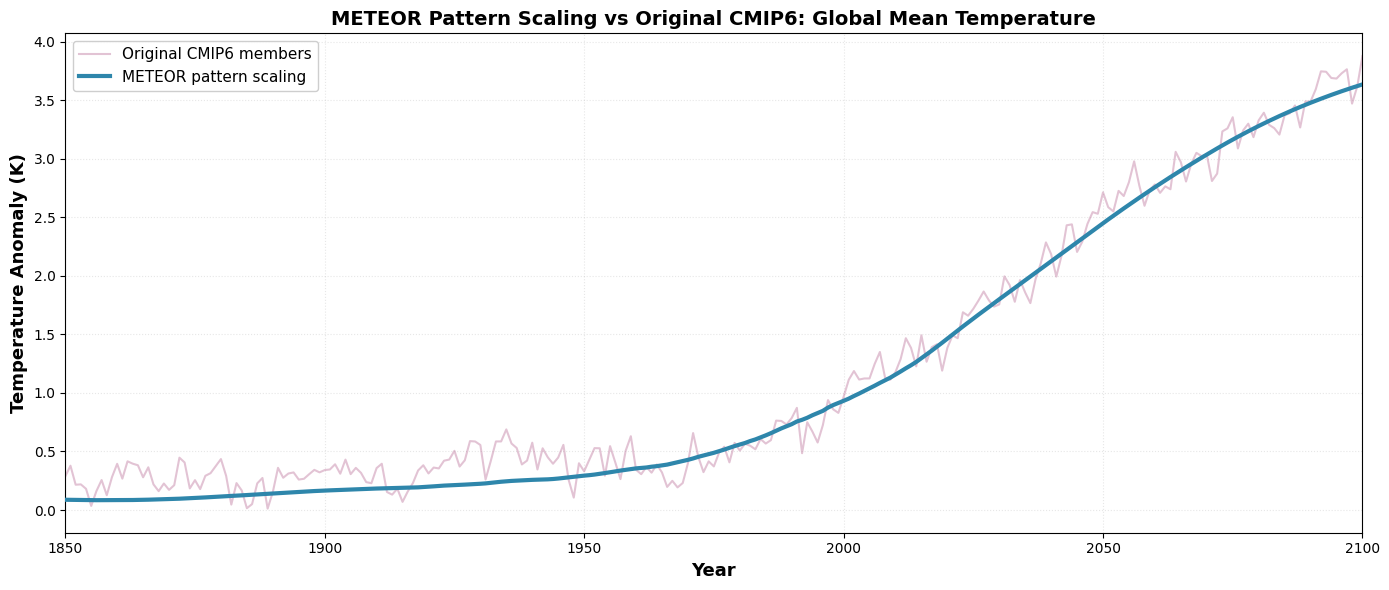


✅ Comparison plot created
   METEOR prediction: 351 years
   Original CMIP6: 251 years
   CMIP6 ensemble members: 1

💡 The METEOR pattern scaling captures the forced response
   without the internal variability present in individual CMIP6 members.


In [10]:
# Compare METEOR pattern scaling prediction with original CMIP6 annual data
print("\n📊 Comparing METEOR pattern scaling with original CMIP6 data...")

# Get METEOR prediction (annual, already calculated)
meteor_prediction_global = prpatt.global_mean(temperature_prediction).values

# Create time axes
years_original = np.arange(1850, 1850 + len(original_ssp245_annual_mean.values[0]))
years_meteor = np.arange(0, len(meteor_prediction_global))+1750  # Starts at year 0

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original CMIP6 ensemble members
for i in range(ssp245_annual.shape[0]):
    ax.plot(years_original, original_ssp245_annual_mean.values[i], 
            color='#A23B72', alpha=0.3, linewidth=1.5, 
            label='Original CMIP6 members' if i == 0 else '')

# Plot METEOR prediction
ax.plot(years_meteor, meteor_prediction_global, 
        color='#2E86AB', linewidth=3, label='METEOR pattern scaling', 
        linestyle='-', zorder=10)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('METEOR Pattern Scaling vs Original CMIP6: Global Mean Temperature', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.show()

print(f"\n✅ Comparison plot created")
print(f"   METEOR prediction: {len(meteor_prediction_global)} years")
print(f"   Original CMIP6: {len(original_ssp245_annual_mean.values[0])} years")
print(f"   CMIP6 ensemble members: {ssp245_annual.shape[0]}")
print("\n💡 The METEOR pattern scaling captures the forced response")
print("   without the internal variability present in individual CMIP6 members.")

## 7. Train Noise Model and Generate IC Ensemble

In [11]:
# Train noise model from CMIP6 data
from meteor.noise_generator import train_noise_model_from_cmip6, MeteorNoiseGenerator
from meteor import prpatt

# Get variable name from data_getter
variable_name = data_getter.flds[0]

# Get cache path using data getter helper
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")
noise_cache_file = data_getter.get_noise_model_cache_path(
    model_name, variable_name, noise_cache_dir
)

# Validate cache using data getter method
is_valid, tas_noise_model, info = data_getter.validate_noise_model_cache(
    noise_cache_file, variable_name, n_modes=40, lag_order=2
)

if is_valid:
    print(f"✅ {info['message']}")
    
    # Still need monthly_prediction and monthly_warming for ensemble generation
    print("   Preparing monthly prediction data...")
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    print(f"✅ Noise model loaded from cache")
else:
    print(f"⚠️  {info['message']}")
    print(f"🔧 Training new noise model for variable '{variable_name}'...")
    
    # Convert annual predictions to monthly
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    # Skip first 100 years (spin-up)
    monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months
    
    # Train the noise model
    tas_noise_model = train_noise_model_from_cmip6(
        data_getter,
        experiments=["historical", "ssp245"],
        model_name=model_name,
        variable_name=variable_name,
        n_modes=40,  # Number of PCA modes
        lag_order=2,  # Temporal lag
        custom_global_temp=monthly_warming_trimmed,
        use_picontrol_baseline=True,
        cache_dir=noise_cache_dir
    )
    
    print(f"✅ Noise model trained successfully for '{variable_name}'")
    print(f"   Training length: {len(monthly_warming_trimmed)//12} years")


Model loaded from /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
✅ Cache valid: variable=tas, n_modes=40, lag_order=2
   Preparing monthly prediction data...
✅ Noise model loaded from cache
✅ Noise model loaded from cache


### Comprehensive Demonstration: Global, Regional, and Point-Scale

Create a 3-panel figure showing 100-member ensembles at different spatial scales.

In [12]:
# Generate ensemble for demonstration
# Use 100 members for global/regional, 1000 members for Oslo point analysis

n_demo = 100  # For global and regional means
n_oslo = 1000  # For Oslo point-scale (better statistics for degree days)

start = time.time()

# Generate stochastic PCs for global/regional analysis
demo_pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_demo,
    random_seed=123
)
print(f"✅ Generated {n_demo} stochastic PCs for global/regional")

# Generate additional stochastic PCs for Oslo
oslo_pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_oslo,
    random_seed=456
)
print(f"✅ Generated {n_oslo} stochastic PCs for Oslo point analysis")


✅ Generated 100 stochastic PCs for global/regional
✅ Generated 1000 stochastic PCs for Oslo point analysis
✅ Generated 1000 stochastic PCs for Oslo point analysis


In [13]:
# Load original CESM2 SSP245 data for comparison
print("📥 Loading original CESM2 SSP245 monthly data from cache...")

ssp245_data = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=True
)["tas"]

pictrl_data = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=True
)["tas"]

# Calculate global mean for the original SSP245 data
original_pictrl_global_mean = calculate_global_mean(pictrl_data)
original_global_mean = calculate_global_mean(ssp245_data) - np.mean(original_pictrl_global_mean)

# Calculate regional means for NEU (Northern Europe)
original_regional_mean = calculate_regional_mean(ssp245_data, "NEU")
original_pictrl_regional_mean = calculate_regional_mean(pictrl_data, "NEU")

print(f"✅ Original CESM2 data loaded")
print(f"   SSP245 shape: {ssp245_data.shape}")
print(f"   piControl shape: {pictrl_data.shape}")
print(f"   Global mean calculated")
print(f"   NEU regional mean calculated: {original_regional_mean.attrs['region_name']}")



INFO: Loading data from cache: CESM2_historical_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/historical/tas
INFO: ✓ Using cached monthly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_monthly.nc
INFO: Loading data from cache: CESM2_ssp245_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/ssp245/tas
INFO: ✓ Using cached monthly data for CESM2/ssp245/tas


📥 Loading original CESM2 SSP245 monthly data from cache...


INFO: Loading data from cache: CESM2_piControl_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/piControl/tas
INFO: ✓ Using cached monthly data for CESM2/piControl/tas


✅ Original CESM2 data loaded
   SSP245 shape: (1, 3012, 192, 288)
   piControl shape: (1, 600, 192, 288)
   Global mean calculated
   NEU regional mean calculated: N.Europe


In [14]:
monthly_prediction_global_mean = prpatt.global_mean(monthly_prediction)
monthly_prediction_neu_mean = calculate_regional_mean(monthly_prediction, "NEU")

In [15]:

# 1. Global mean ensemble
demo_global = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_global_mean
)
print(f"✅ Global mean: {demo_global.shape}")

# 2. Regional mean ensemble (NEU - Northern Europe)
demo_neu = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='NEU',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_neu_mean
)
print(f"✅ NEU regional mean: {demo_neu.shape}")

# 3. Point-scale ensemble (Oslo: 59.9°N, 10.8°E) - using larger ensemble
oslo_lat, oslo_lon = 59.9, 10.8
lat_idx, lon_idx = tas_noise_model._find_nearest_gridpoint(oslo_lat, oslo_lon)
oslo_base = monthly_prediction[:, lat_idx, lon_idx]
original_oslo_anomaly_values = ssp245_data[:, :, lat_idx, lon_idx] - np.mean(pictrl_data[:, :, lat_idx, lon_idx])

demo_oslo = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    lat=oslo_lat,
    lon=oslo_lon,
    stochastic_pcs=oslo_pcs,  # Use larger ensemble for Oslo
    noise_only=True,
    add_base=oslo_base
)
print(f"✅ Oslo point: {demo_oslo.shape}")

elapsed_demo = time.time() - start
print(f"\n⏱️  Total generation time: {elapsed_demo:.2f}s")
print(f"   Global/Regional: {elapsed_demo/(n_demo):.3f}s per realization × 2 locations")
print(f"   Oslo: {elapsed_demo/(n_oslo):.4f}s per realization × 1 location")
print("="*70)

✅ Global mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ Oslo point: (1000, 4212)

⏱️  Total generation time: 44.00s
   Global/Regional: 0.440s per realization × 2 locations
   Oslo: 0.0440s per realization × 1 location
✅ Oslo point: (1000, 4212)

⏱️  Total generation time: 44.00s
   Global/Regional: 0.440s per realization × 2 locations
   Oslo: 0.0440s per realization × 1 location


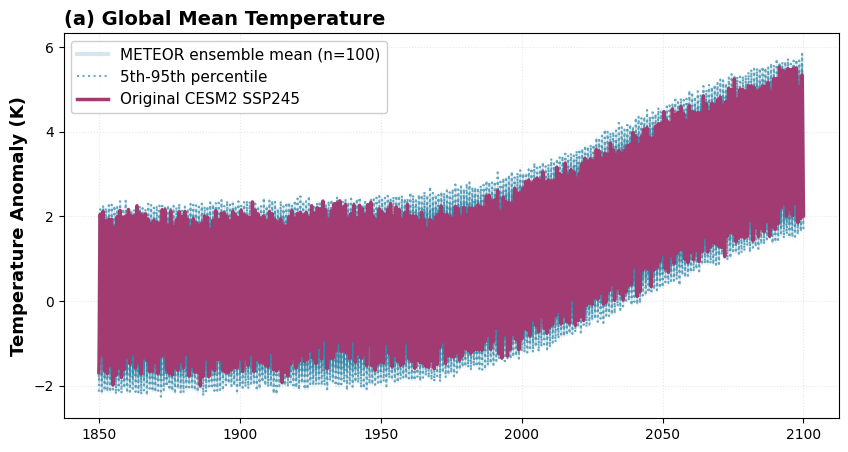

In [16]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 1850, 2100

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10,alpha=0.2)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='-',
        label=f'Original {model_name} SSP245', zorder=10, marker='', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)


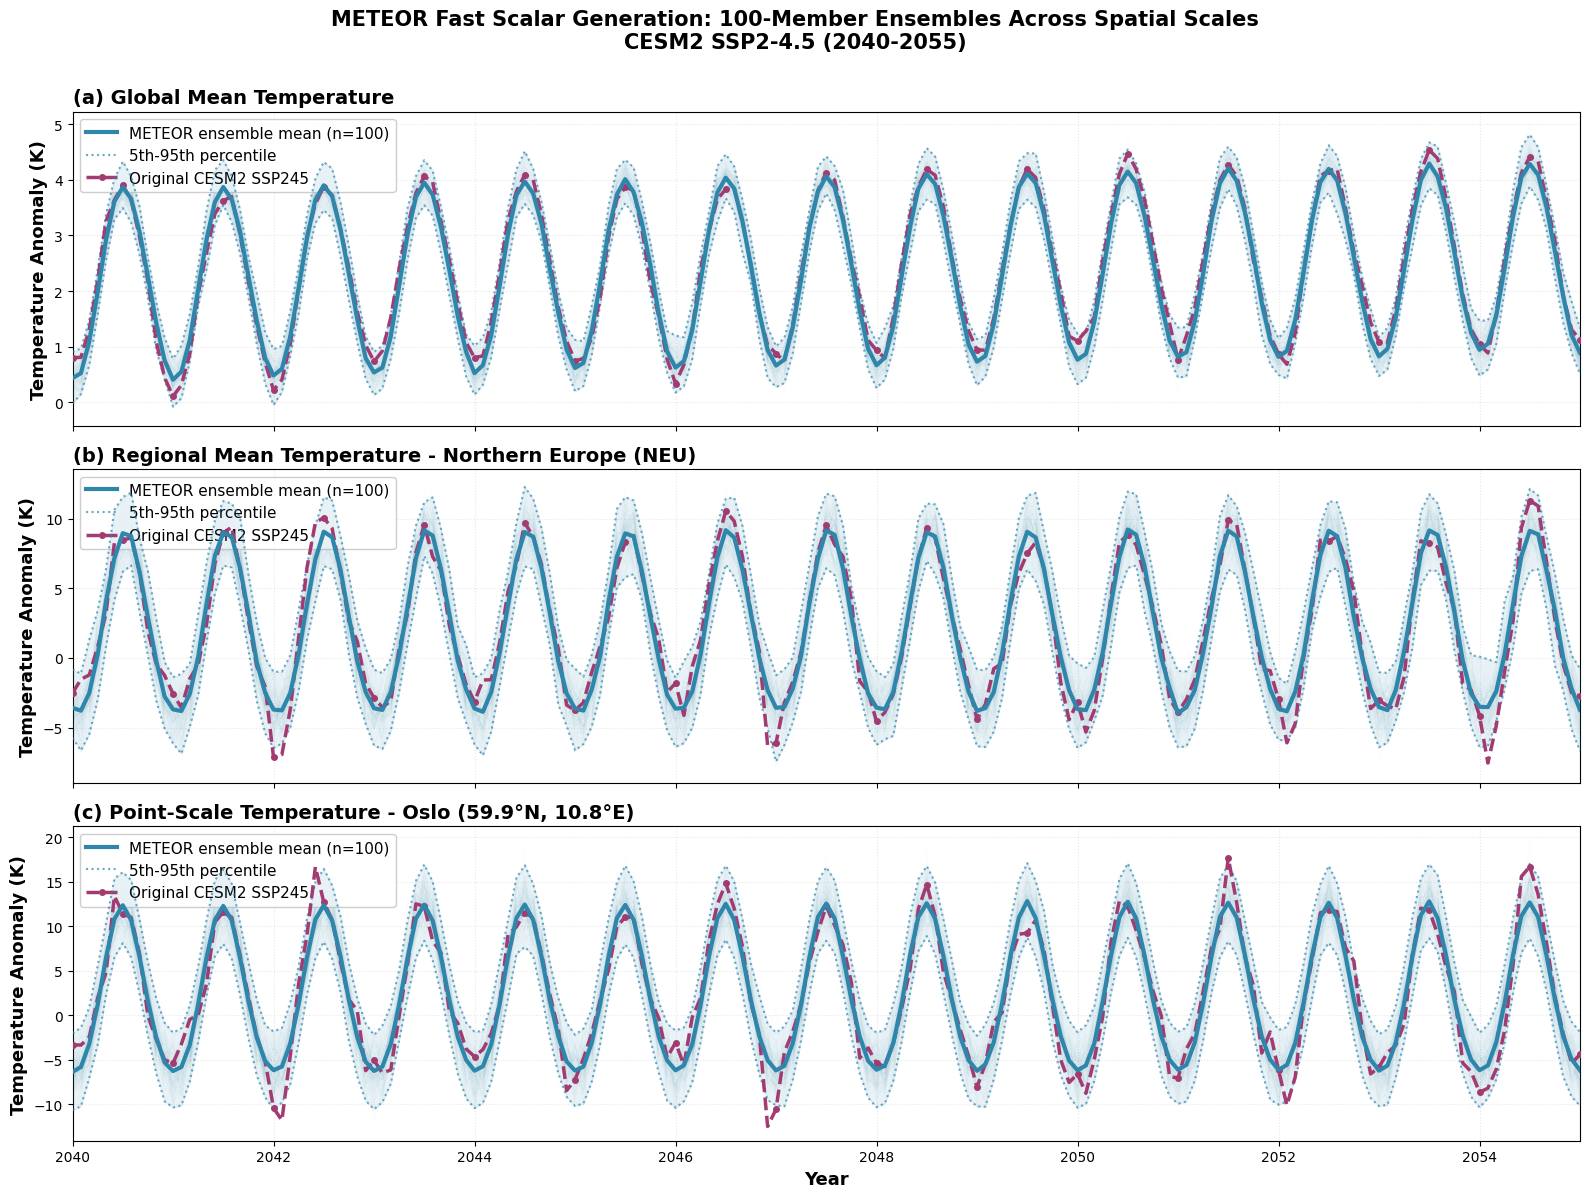


✅ Created comprehensive 3-panel demonstration figure
   Showing global, regional (NEU), and point-scale (Oslo) ensembles
   Period: 2040-2055
   Ensemble size: 100 members
   All scales share identical stochastic variability!


In [17]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 2040, 2055

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes[0]

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 2: REGIONAL MEAN (Northern Europe)
# ============================================================================
ax = axes[1]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_neu.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_neu = demo_neu.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_neu[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_neu = demo_neu.quantile(0.01, dim='realization').values[offset:]
perc_95_neu = demo_neu.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_neu[time_mask_offset], perc_95_neu[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
original_neu_anomaly = original_regional_mean - original_pictrl_regional_mean.mean()
ax.plot(time_plot, original_neu_anomaly.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title(f'(b) Regional Mean Temperature - Northern Europe (NEU)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 3: POINT-SCALE (Oslo)
# ============================================================================
ax = axes[2]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_oslo.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_oslo = demo_oslo.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_oslo = demo_oslo.quantile(0.01, dim='realization').values[offset:]
perc_95_oslo = demo_oslo.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_oslo[time_mask_offset], perc_95_oslo[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_oslo_anomaly_values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_title(f'(c) Point-Scale Temperature - Oslo ({oslo_lat}°N, {oslo_lon}°E)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# Set x-axis limits
for ax in axes:
    ax.set_xlim(zoom_start, zoom_end)

# Overall title
fig.suptitle(f'METEOR Fast Scalar Generation: {n_demo}-Member Ensembles Across Spatial Scales\n{model_name} SSP2-4.5 ({zoom_start}-{zoom_end})', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"\n✅ Created comprehensive 3-panel demonstration figure")
print(f"   Showing global, regional (NEU), and point-scale (Oslo) ensembles")
print(f"   Period: {zoom_start}-{zoom_end}")
print(f"   Ensemble size: {n_demo} members")
print(f"   All scales share identical stochastic variability!")


### Ensemble Adequacy Testing

Test whether the original CMIP6 simulations fall within the METEOR ensemble distribution as expected. If the ensemble is well-calibrated, the original data should be uniformly distributed across the ensemble percentiles.

In [18]:
def calculate_ensemble_rank(observation, ensemble):
    """
    Calculate the rank of an observation within an ensemble distribution.
    
    Parameters
    ----------
    observation : array-like
        Observed values (time series)
    ensemble : array-like
        Ensemble members (n_members x time)
        
    Returns
    -------
    ranks : array
        Rank percentiles (0-1) for each timestep
    """
    n_members = ensemble.shape[0]
    ranks = np.zeros(len(observation))
    
    for t in range(len(observation)):
        # Count how many ensemble members are below the observation
        count_below = np.sum(ensemble[:, t] < observation[t])
        # Rank as percentile (0 to 1)
        ranks[t] = count_below / n_members
    
    return ranks


# Calculate ranks for each region across the overlapping time period
print("🔍 Calculating ensemble ranks for original CMIP6 data...")
print("="*70)

# Use the time period where we have both METEOR and original data (after offset)
analysis_start_idx = offset  # Start after the offset
analysis_length = min(len(original_global_mean.values[0]), 
                      len(demo_global.values[0]) - offset)

# 1. Global mean ranks (first CMIP6 ensemble member)
global_obs = original_global_mean.values[0, :analysis_length]
global_ens = demo_global.values[:, offset:offset+analysis_length]
global_ranks = calculate_ensemble_rank(global_obs, global_ens)

print(f"✅ Global mean ranks calculated: {len(global_ranks)} timesteps")
print(f"   Mean rank: {np.mean(global_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(global_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 2. Regional mean ranks (NEU - first CMIP6 ensemble member)
neu_obs = original_neu_anomaly.values[0, :analysis_length]
neu_ens = demo_neu.values[:, offset:offset+analysis_length]
neu_ranks = calculate_ensemble_rank(neu_obs, neu_ens)

print(f"✅ NEU regional ranks calculated: {len(neu_ranks)} timesteps")
print(f"   Mean rank: {np.mean(neu_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(neu_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 3. Point-scale ranks (Oslo - first CMIP6 ensemble member)
# Convert to numpy array if it's an xarray DataArray
if hasattr(original_oslo_anomaly_values, 'values'):
    oslo_obs = original_oslo_anomaly_values.values[0, :analysis_length]
else:
    oslo_obs = original_oslo_anomaly_values[0, :analysis_length]
oslo_ens = demo_oslo.values[:, offset:offset+analysis_length]
oslo_ranks = calculate_ensemble_rank(oslo_obs, oslo_ens)

print(f"✅ Oslo point ranks calculated: {len(oslo_ranks)} timesteps")
print(f"   Mean rank: {np.mean(oslo_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(oslo_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

print("="*70)
print("\n💡 For a well-calibrated ensemble:")
print("   - Ranks should be uniformly distributed between 0 and 1")
print("   - Mean rank ≈ 0.5")
print(f"   - Std rank ≈ {1/np.sqrt(12):.3f} (1/√12 for uniform distribution)")

🔍 Calculating ensemble ranks for original CMIP6 data...
✅ Global mean ranks calculated: 3012 timesteps
   Mean rank: 0.614 (expected: 0.5)
   Std rank: 0.273 (expected: 0.289)
✅ NEU regional ranks calculated: 3012 timesteps
   Mean rank: 0.498 (expected: 0.5)
   Std rank: 0.272 (expected: 0.289)
✅ Oslo point ranks calculated: 3012 timesteps
   Mean rank: 0.515 (expected: 0.5)
   Std rank: 0.283 (expected: 0.289)

💡 For a well-calibrated ensemble:
   - Ranks should be uniformly distributed between 0 and 1
   - Mean rank ≈ 0.5
   - Std rank ≈ 0.289 (1/√12 for uniform distribution)


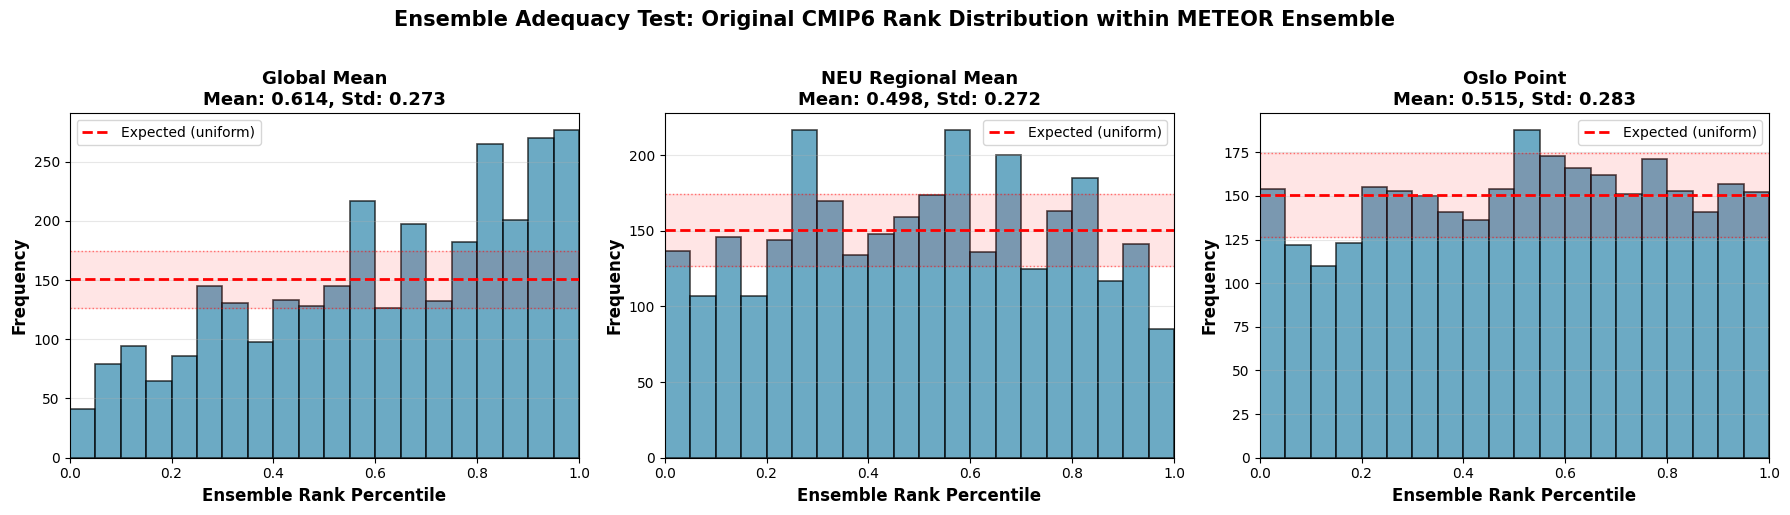


📊 Histogram Analysis:
   If the ensemble is well-calibrated, histograms should be approximately flat
   (uniform distribution across all percentile bins)
   Number of timesteps analyzed: 3012
   Expected count per bin: 150.6
   95% confidence interval: [126.7, 174.5]


In [19]:
# Create histograms showing rank distributions for all three regions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
expected_count = len(global_ranks) / 20  # Expected count per bin for uniform distribution

regions = [
    ('Global Mean', global_ranks, axes[0]),
    ('NEU Regional Mean', neu_ranks, axes[1]),
    ('Oslo Point', oslo_ranks, axes[2])
]

for region_name, ranks, ax in regions:
    # Plot histogram
    counts, edges, patches = ax.hist(ranks, bins=bins, alpha=0.7, color='#2E86AB', 
                                      edgecolor='black', linewidth=1.2)
    
    # Plot expected uniform distribution line
    ax.axhline(expected_count, color='red', linestyle='--', linewidth=2, 
               label=f'Expected (uniform)', zorder=10)
    
    # Add shaded confidence interval for uniform distribution (±2σ)
    # For binomial: σ = sqrt(n*p*(1-p)) where p=1/20, n=total_timesteps
    p = 1/20
    sigma = np.sqrt(len(ranks) * p * (1-p))
    ax.axhline(expected_count + 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(expected_count - 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.fill_between([0, 1], expected_count - 2*sigma, expected_count + 2*sigma,
                     color='red', alpha=0.1, zorder=1)
    
    # Labels and formatting
    ax.set_xlabel('Ensemble Rank Percentile', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{region_name}\nMean: {np.mean(ranks):.3f}, Std: {np.std(ranks):.3f}', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)

plt.suptitle('Ensemble Adequacy Test: Original CMIP6 Rank Distribution within METEOR Ensemble', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Histogram Analysis:")
print("   If the ensemble is well-calibrated, histograms should be approximately flat")
print("   (uniform distribution across all percentile bins)")
print(f"   Number of timesteps analyzed: {len(global_ranks)}")
print(f"   Expected count per bin: {expected_count:.1f}")
print(f"   95% confidence interval: [{expected_count - 2*sigma:.1f}, {expected_count + 2*sigma:.1f}]")

## 8. Calculate Heating and Cooling Degree Days for Oslo

Now we'll use the Oslo ensemble temperatures to calculate heating and cooling degree days

In [20]:
# Import the degree days calculator
from meteor.impacts import DegreeDaysCalculator

# Set base temperature for degree days calculation (18°C is standard for residential)
BASE_TEMPERATURE = 18.0

# Initialize the calculator
dd_calculator = DegreeDaysCalculator(base_temperature=BASE_TEMPERATURE)

print(f"🔧 Degree Days Calculator initialized")
print(f"   Base temperature: {BASE_TEMPERATURE}°C")
print(f"   Method: Isaac and van Vuuren (2009)")

# Calculate degree days for each ensemble member
# IMPORTANT: demo_oslo contains temperature ANOMALIES (not absolute temperatures)
# We need to add the piControl baseline to get absolute temperatures

# Get the piControl baseline for Oslo
oslo_picontrol_baseline = pictrl_data[:, :, lat_idx, lon_idx].mean()  # Mean over all piControl data
print(f"📊 Oslo piControl baseline: {oslo_picontrol_baseline.values:.2f} K ({oslo_picontrol_baseline.values - 273.15:.2f}°C)")

oslo_dd_results = []

print(f"🔄 Calculating degree days for {n_oslo} ensemble members...")

for i in range(n_oslo):
    # Get this ensemble member's temperature anomaly
    # demo_oslo has dimensions (realization, month)
    oslo_temp_anomaly = demo_oslo.isel(realization=i)
    
    # Add piControl baseline to get absolute temperature in Kelvin
    oslo_temp_kelvin = oslo_temp_anomaly + oslo_picontrol_baseline
    
    # Convert to Celsius for degree days calculation
    oslo_temp_celsius = oslo_temp_kelvin - 273.15 
    
    # Calculate degree days
    dd_result = dd_calculator.calculate(oslo_temp_celsius)
    oslo_dd_results.append(dd_result)
    
    # Progress update every 100 members
    if (i + 1) % 100 == 0:
        print(f"   Processed {i + 1}/{n_oslo} members...")

print(f"✅ Degree days calculated for {len(oslo_dd_results)} ensemble members")
print(f"   Available metrics: {list(oslo_dd_results[0].keys())}")

# Calculate degree days for original CESM2 data
print(f"\n🔄 Calculating degree days for original CESM2 ensemble members...")
oslo_dd_original = []

for i in range(ssp245_data.shape[0]):
    # Get absolute temperature (not anomaly) for this CESM2 ensemble member
    oslo_temp_original = ssp245_data[i, :, lat_idx, lon_idx]
    
    # Convert to Celsius for degree days calculation
    oslo_temp_celsius_original = oslo_temp_original - 273.15
    
    # Calculate degree days
    dd_result_original = dd_calculator.calculate(oslo_temp_celsius_original)
    oslo_dd_original.append(dd_result_original)

print(f"✅ Degree days calculated for {len(oslo_dd_original)} original CESM2 members")


🔧 Degree Days Calculator initialized
   Base temperature: 18.0°C
   Method: Isaac and van Vuuren (2009)
📊 Oslo piControl baseline: 278.16 K (5.01°C)
🔄 Calculating degree days for 1000 ensemble members...
   Processed 100/1000 members...
   Processed 100/1000 members...
   Processed 200/1000 members...
   Processed 200/1000 members...
   Processed 300/1000 members...
   Processed 300/1000 members...
   Processed 400/1000 members...
   Processed 400/1000 members...
   Processed 500/1000 members...
   Processed 500/1000 members...
   Processed 600/1000 members...
   Processed 600/1000 members...
   Processed 700/1000 members...
   Processed 700/1000 members...
   Processed 800/1000 members...
   Processed 800/1000 members...
   Processed 900/1000 members...
   Processed 900/1000 members...
   Processed 1000/1000 members...
✅ Degree days calculated for 1000 ensemble members
   Available metrics: ['monthly_hdd', 'monthly_cdd', 'annual_hdd', 'annual_cdd']

🔄 Calculating degree days for origi

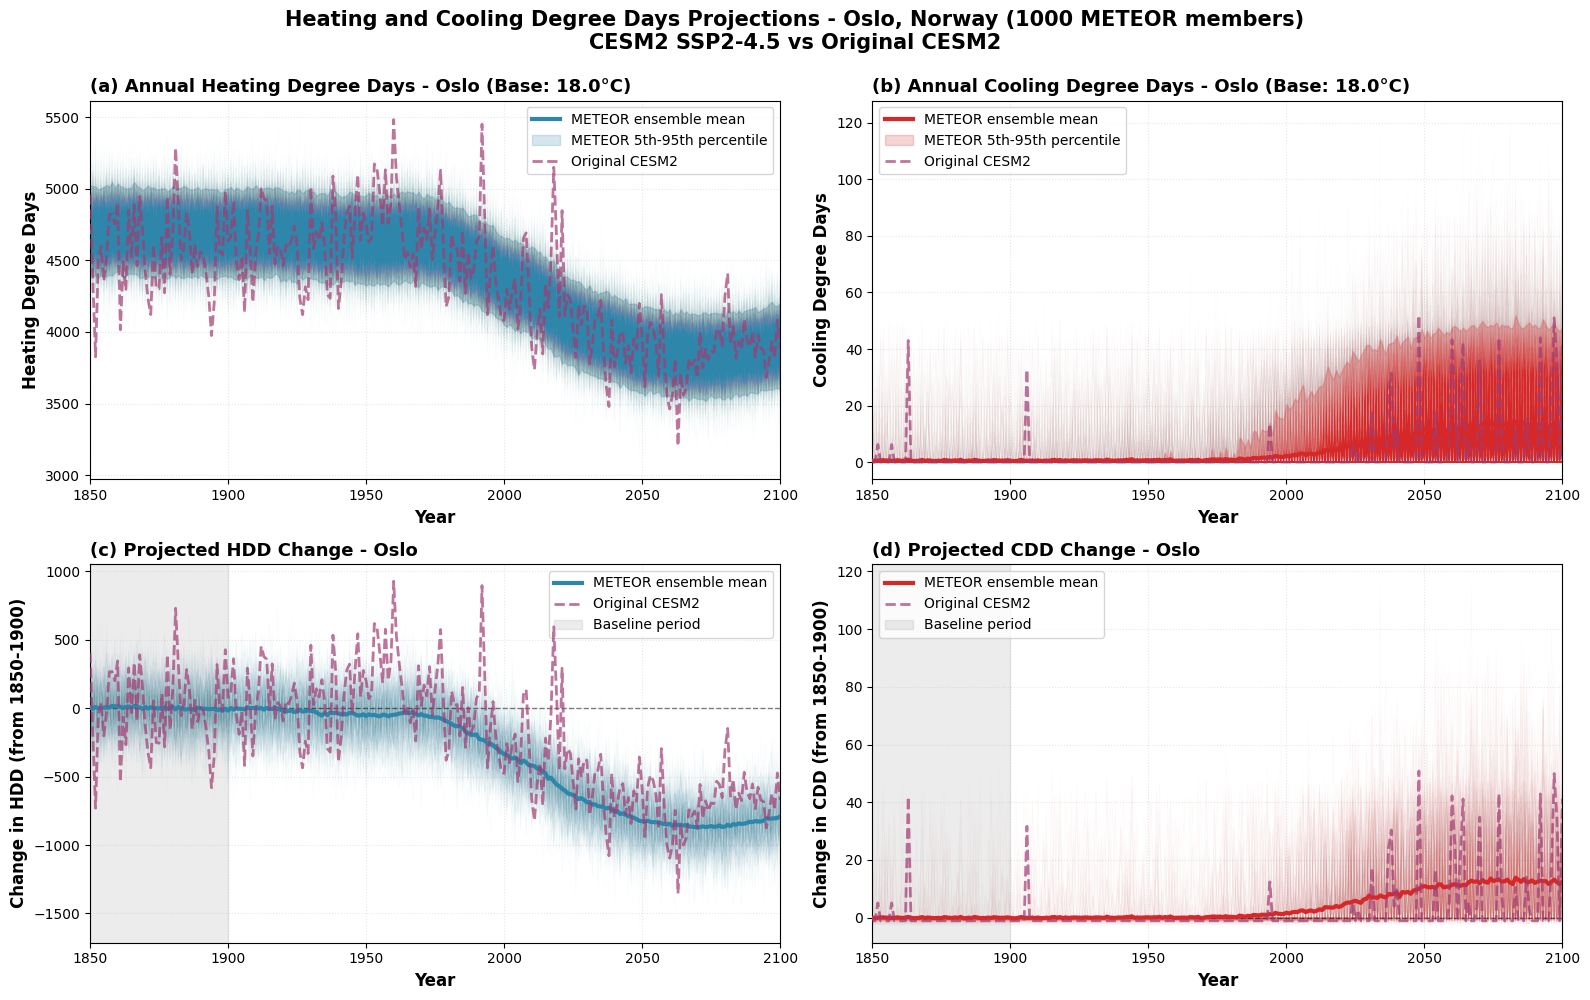


📊 Oslo Degree Days Summary
   Baseline period: 1850-1900
   
   METEOR Ensemble (1000 members):
   Heating Degree Days (HDD):
      Baseline (1850-1900): 4696 ± 26 degree-days
      Year 2100: 3905 ± 180 degree-days
      Change: -791 degree-days (-16.9%)
   
   Cooling Degree Days (CDD):
      Baseline (1850-1900): 1 ± 1 degree-days
      Year 2100: 13 ± 19 degree-days
      Change: 12 degree-days (2244.3%)
   
   Original CESM2 (1 members):
   Heating Degree Days (HDD):
      Baseline (1850-1900): 4557 degree-days
      Year 2100: 3886 degree-days
      Change: -671 degree-days (-14.7%)
   
   Cooling Degree Days (CDD):
      Baseline (1850-1900): 1 degree-days
      Year 2100: 42 degree-days
      Change: 41 degree-days (3793.4%)
   
   💡 Decreasing HDD indicates reduced heating demand
      Increasing CDD indicates increased cooling demand


In [21]:
# Visualize heating and cooling degree days for Oslo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time axis for plotting (annual degree days)
# The degree days start at year 0 (corresponding to 1750), so we add 1750
years_dd = np.arange(len(oslo_dd_results[0]['annual_hdd'])) + 1750

# Extract annual HDD and CDD from all ensemble members
annual_hdd_ensemble = np.array([dd['annual_hdd'].values for dd in oslo_dd_results])
annual_cdd_ensemble = np.array([dd['annual_cdd'].values for dd in oslo_dd_results])

# Extract annual HDD and CDD from original CESM2 data
# Original data starts at 1850 (year index 100 in the full timeline)
years_dd_original = ssp245_data['month'].values / 12 + 1850
years_dd_original_annual = np.arange(1850, 1850 + len(oslo_dd_original[0]['annual_hdd']))

annual_hdd_original = np.array([dd['annual_hdd'].values for dd in oslo_dd_original])
annual_cdd_original = np.array([dd['annual_cdd'].values for dd in oslo_dd_original])

# Colors
hdd_color = '#2E86AB'  # Blue for heating
cdd_color = '#D62828'  # Red for cooling
original_color = '#A23B72'  # Purple/magenta for original CESM2

# ============================================================================
# Panel 1: Annual Heating Degree Days (Full Period)
# ============================================================================
ax = axes[0, 0]

# Plot individual ensemble members (with lower alpha for 1000 members)
for i in range(n_oslo):
    ax.plot(years_dd, annual_hdd_ensemble[i], 
            color=hdd_color, alpha=0.01, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_hdd = annual_hdd_ensemble.mean(axis=0)
ax.plot(years_dd, ensemble_mean_hdd, 
        color=hdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Plot percentiles
perc_05_hdd = np.percentile(annual_hdd_ensemble, 5, axis=0)
perc_95_hdd = np.percentile(annual_hdd_ensemble, 95, axis=0)
ax.fill_between(years_dd, perc_05_hdd, perc_95_hdd, 
                color=hdd_color, alpha=0.2, label='METEOR 5th-95th percentile')

# Overlay original CESM2 data
for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, annual_hdd_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Heating Degree Days', fontsize=12, fontweight='bold')
ax.set_title(f'(a) Annual Heating Degree Days - Oslo (Base: {BASE_TEMPERATURE}°C)', 
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(1850, 2100)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper right')

# ============================================================================
# Panel 2: Annual Cooling Degree Days (Full Period)
# ============================================================================
ax = axes[0, 1]

# Plot individual ensemble members
for i in range(n_oslo):
    ax.plot(years_dd, annual_cdd_ensemble[i], 
            color=cdd_color, alpha=0.01, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_cdd = annual_cdd_ensemble.mean(axis=0)
ax.plot(years_dd, ensemble_mean_cdd, 
        color=cdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Plot percentiles
perc_05_cdd = np.percentile(annual_cdd_ensemble, 5, axis=0)
perc_95_cdd = np.percentile(annual_cdd_ensemble, 95, axis=0)
ax.fill_between(years_dd, perc_05_cdd, perc_95_cdd, 
                color=cdd_color, alpha=0.2, label='METEOR 5th-95th percentile')

# Overlay original CESM2 data
for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, annual_cdd_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cooling Degree Days', fontsize=12, fontweight='bold')
ax.set_title(f'(b) Annual Cooling Degree Days - Oslo (Base: {BASE_TEMPERATURE}°C)', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1850, 2100)


# ============================================================================
# Panel 3: HDD Change (Full period with baseline as reference)
# ============================================================================
ax = axes[1, 0]

# Calculate baseline (1850-1900) for reference
baseline_mask = (years_dd >= 1850) & (years_dd <= 1900)
baseline_hdd = annual_hdd_ensemble[:, baseline_mask].mean(axis=1)  # Mean per member

# Calculate change for all years relative to each member's baseline
hdd_change_full = annual_hdd_ensemble - baseline_hdd[:, np.newaxis]

# Plot ensemble spread (subsample for visibility)
plot_sample = min(200, n_oslo)  # Plot max 200 members for visibility
plot_indices = np.linspace(0, n_oslo-1, plot_sample, dtype=int)

for i in plot_indices:
    ax.plot(years_dd, hdd_change_full[i], 
            color=hdd_color, alpha=0.02, linewidth=0.6)

# Plot ensemble mean change
mean_hdd_change_full = hdd_change_full.mean(axis=0)
ax.plot(years_dd, mean_hdd_change_full, 
        color=hdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Calculate and plot original CESM2 change
baseline_mask_original = (years_dd_original_annual >= 1850) & (years_dd_original_annual <= 1900)
baseline_hdd_original = annual_hdd_original[:, baseline_mask_original].mean(axis=1)
hdd_change_original = annual_hdd_original - baseline_hdd_original[:, np.newaxis]

for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, hdd_change_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

# Add zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add shaded region for baseline period
ax.axvspan(1850, 1900, alpha=0.15, color='gray', label='Baseline period')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in HDD (from 1850-1900)', fontsize=12, fontweight='bold')
ax.set_title('(c) Projected HDD Change - Oslo', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(1850, 2100)

# ============================================================================
# Panel 4: CDD Change (Full period with baseline as reference)
# ============================================================================
ax = axes[1, 1]

# Calculate CDD change for all years
baseline_cdd = annual_cdd_ensemble[:, baseline_mask].mean(axis=1)
cdd_change_full = annual_cdd_ensemble - baseline_cdd[:, np.newaxis]

# Plot ensemble spread (subsample for visibility)
for i in plot_indices:
    ax.plot(years_dd, cdd_change_full[i], 
            color=cdd_color, alpha=0.02, linewidth=0.6)

# Plot ensemble mean change
mean_cdd_change_full = cdd_change_full.mean(axis=0)
ax.plot(years_dd, mean_cdd_change_full, 
        color=cdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Calculate and plot original CESM2 change
baseline_cdd_original = annual_cdd_original[:, baseline_mask_original].mean(axis=1)
cdd_change_original = annual_cdd_original - baseline_cdd_original[:, np.newaxis]

for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, cdd_change_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

# Add zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add shaded region for baseline period
ax.axvspan(1850, 1900, alpha=0.15, color='gray', label='Baseline period')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in CDD (from 1850-1900)', fontsize=12, fontweight='bold')
ax.set_title('(d) Projected CDD Change - Oslo', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1850, 2100)

plt.suptitle(f'Heating and Cooling Degree Days Projections - Oslo, Norway ({n_oslo} METEOR members)\n{model_name} SSP2-4.5 vs Original CESM2', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
baseline_hdd_mean = baseline_hdd.mean()
baseline_hdd_std = baseline_hdd.std()
future_2100_hdd_mean = annual_hdd_ensemble[:, years_dd == 2100].mean()
future_2100_hdd_std = annual_hdd_ensemble[:, years_dd == 2100].std()

baseline_cdd_mean = baseline_cdd.mean()
baseline_cdd_std = baseline_cdd.std()
future_2100_cdd_mean = annual_cdd_ensemble[:, years_dd == 2100].mean()
future_2100_cdd_std = annual_cdd_ensemble[:, years_dd == 2100].std()

# Original CESM2 statistics
baseline_hdd_original_mean = baseline_hdd_original.mean()
baseline_cdd_original_mean = baseline_cdd_original.mean()
future_2100_hdd_original_mean = annual_hdd_original[:, years_dd_original_annual == 2100].mean()
future_2100_cdd_original_mean = annual_cdd_original[:, years_dd_original_annual == 2100].mean()

print(f"\n📊 Oslo Degree Days Summary")
print("="*70)
print(f"   Baseline period: 1850-1900")
print(f"   ")
print(f"   METEOR Ensemble ({n_oslo} members):")
print(f"   Heating Degree Days (HDD):")
print(f"      Baseline (1850-1900): {baseline_hdd_mean:.0f} ± {baseline_hdd_std:.0f} degree-days")
print(f"      Year 2100: {future_2100_hdd_mean:.0f} ± {future_2100_hdd_std:.0f} degree-days")
print(f"      Change: {future_2100_hdd_mean - baseline_hdd_mean:.0f} degree-days ({((future_2100_hdd_mean - baseline_hdd_mean)/baseline_hdd_mean*100):.1f}%)")
print(f"   ")
print(f"   Cooling Degree Days (CDD):")
print(f"      Baseline (1850-1900): {baseline_cdd_mean:.0f} ± {baseline_cdd_std:.0f} degree-days")
print(f"      Year 2100: {future_2100_cdd_mean:.0f} ± {future_2100_cdd_std:.0f} degree-days")
print(f"      Change: {future_2100_cdd_mean - baseline_cdd_mean:.0f} degree-days ({((future_2100_cdd_mean - baseline_cdd_mean)/baseline_cdd_mean*100 if baseline_cdd_mean > 0 else float('inf')):.1f}%)")
print(f"   ")
print(f"   Original CESM2 ({len(oslo_dd_original)} members):")
print(f"   Heating Degree Days (HDD):")
print(f"      Baseline (1850-1900): {baseline_hdd_original_mean:.0f} degree-days")
print(f"      Year 2100: {future_2100_hdd_original_mean:.0f} degree-days")
print(f"      Change: {future_2100_hdd_original_mean - baseline_hdd_original_mean:.0f} degree-days ({((future_2100_hdd_original_mean - baseline_hdd_original_mean)/baseline_hdd_original_mean*100):.1f}%)")
print(f"   ")
print(f"   Cooling Degree Days (CDD):")
print(f"      Baseline (1850-1900): {baseline_cdd_original_mean:.0f} degree-days")
print(f"      Year 2100: {future_2100_cdd_original_mean:.0f} degree-days")
print(f"      Change: {future_2100_cdd_original_mean - baseline_cdd_original_mean:.0f} degree-days ({((future_2100_cdd_original_mean - baseline_cdd_original_mean)/baseline_cdd_original_mean*100 if baseline_cdd_original_mean > 0 else float('inf')):.1f}%)")
print(f"   ")
print(f"   💡 Decreasing HDD indicates reduced heating demand")
print(f"      Increasing CDD indicates increased cooling demand")


# Precip test

In [52]:
# Initialize data getter for precipitation
print("📥 Setting up CMIP6 data getter for precipitation...")

pr_data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["pr"],  # Precipitation
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'],
    enable_cache=True
)

print(f"✅ Precipitation data getter initialized")
print(f"   Available models: {pr_data_getter.get_models_avail()}")

INFO: Setting up local cache for CMIP6 data at: /Users/bensan/Documents/Github/METEOR/.cache/cmip6. This will improve performance by storing downloaded data locally.
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv


📥 Setting up CMIP6 data getter for precipitation...
✅ Precipitation data getter initialized
   Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


In [53]:
# Set up precipitation pattern scaling model
pr_model_name = "NorESM2-MM"
pr_scenario = "ssp245"

# Get cache path
pr_cache_dir = os.path.join("..", ".cache", "trained_pattern_scaling_models")
pr_cache_file = pr_data_getter.get_pattern_scaling_cache_path(pr_model_name, pr_cache_dir)

# Validate cache
is_valid_pr, cached_pr_model, pr_info = pr_data_getter.validate_pattern_scaling_cache(
    pr_cache_file, pr_model_name
)

if is_valid_pr:
    print(f"✅ {pr_info['message']}")
    pr_training_data = None
    pr_ssp_config = None
else:
    print(f"⚠️  {pr_info['message']}")
    print(f"🔧 Preparing precipitation training data for {pr_model_name}...")
    
    # Prepare training data
    pr_training_data = pr_data_getter.prepare_pattern_scaling_training_data(
        pr_model_name, pr_scenario
    )
    
    # Detailed NaN diagnostics for precipitation data
    print(f"\n🔍 Detailed NaN Diagnostics for Precipitation Training Data")
    print("="*70)
    
    for exp_name, exp_data in pr_training_data.items():
        if 'pr' in exp_data:
            pr_data = exp_data['pr']
            print(f"\n📊 Experiment: {exp_name}")
            print(f"   Shape: {pr_data.shape}")
            print(f"   Dims: {pr_data.dims}")
            
            # Overall NaN statistics
            nan_mask = np.isnan(pr_data.values)
            total_values = pr_data.size
            nan_count = nan_mask.sum()
            nan_fraction = nan_count / total_values
            
            print(f"   Total NaNs: {nan_count:,} / {total_values:,} ({nan_fraction*100:.2f}%)")
            
            # NaN distribution across dimensions
            if 'time' in pr_data.dims or 'year' in pr_data.dims:
                time_dim = 'time' if 'time' in pr_data.dims else 'year'
                nan_per_time = np.isnan(pr_data.values).sum(axis=tuple(i for i, d in enumerate(pr_data.dims) if d != time_dim))
                print(f"   NaN count range across {time_dim}: {nan_per_time.min():,} - {nan_per_time.max():,}")
                
                # Check if any timestep is fully NaN
                fully_nan_times = np.sum(nan_per_time == pr_data.size / len(pr_data[time_dim]))
                if fully_nan_times > 0:
                    print(f"   ⚠️  {fully_nan_times} timesteps are FULLY NaN!")
            
            # Spatial pattern of NaNs
            if 'lat' in pr_data.dims and 'lon' in pr_data.dims:
                # Sum NaNs across time dimension to see spatial pattern
                time_axis = tuple(i for i, d in enumerate(pr_data.dims) if d not in ['lat', 'lon'])
                nan_spatial = np.isnan(pr_data.values).sum(axis=time_axis) if time_axis else nan_mask
                
                # Count how many grid cells are always NaN
                if time_axis:
                    n_times = np.prod([pr_data.sizes[d] for d in pr_data.dims if d not in ['lat', 'lon']])
                    always_nan = (nan_spatial == n_times).sum()
                    never_nan = (nan_spatial == 0).sum()
                    sometimes_nan = ((nan_spatial > 0) & (nan_spatial < n_times)).sum()
                    
                    print(f"   Grid cells ALWAYS NaN: {always_nan:,} ({always_nan/nan_spatial.size*100:.1f}%)")
                    print(f"   Grid cells NEVER NaN: {never_nan:,} ({never_nan/nan_spatial.size*100:.1f}%)")
                    print(f"   Grid cells SOMETIMES NaN: {sometimes_nan:,} ({sometimes_nan/nan_spatial.size*100:.1f}%)")
            
            # Sample of actual values (non-NaN)
            non_nan_values = pr_data.values[~nan_mask]
            if len(non_nan_values) > 0:
                print(f"   Non-NaN value range: [{non_nan_values.min():.6e}, {non_nan_values.max():.6e}]")
                print(f"   Non-NaN value mean: {non_nan_values.mean():.6e}")
            else:
                print(f"   ⚠️  ALL VALUES ARE NaN!")
    
    print("\n" + "="*70)
    
    # Load SSP configuration
    pr_ssp_config = pr_data_getter.load_ssp_config(pr_scenario)
    print(f"\n✅ Training data prepared")

INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr
INFO: Loading data from cache: NorESM2-MM_abrupt-4xCO2_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/abrupt-4xCO2/pr
INFO: Loading data from cache: NorESM2-MM_historical_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr


⚠️  Cache file not found: ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-aer_pattern_scaling.pkl
🔧 Preparing precipitation training data for NorESM2-MM...
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']

🔍 Detailed NaN Diagnostics for Precipitation Training Data

📊 Experiment: base
   Shape: (1, 150, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   Total NaNs: 0 / 8,294,400 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES NaN: 0 (0.0%)
   Non-NaN value range: [6.388014e-10, 2.354604e-04]
   Non-NaN value mean: 2.700646e-05

📊 Experiment: co2x4
   Shape: (1, 150, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   Total NaNs: 0 / 8,294,400 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES

   Non-NaN value range: [4.765671e-10, 2.625820e-04]
   Non-NaN value mean: 2.726088e-05

📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850

✅ Training data prepared


In [54]:
# Create precipitation pattern scaling model
print("🌍 Creating precipitation pattern scaling model...")

pr_pattern_model = MeteorPatternScaling(
    f"cmip6-{pr_model_name}-pr-aer",
    {"pr": 3} if pr_training_data is None else {"pr": 3},  # 3 patterns for precipitation
    None if pr_training_data is None else lambda key: pr_training_data[key],
    ssp_input=pr_ssp_config,
    from_file=False,
    exp_list=None if pr_training_data is None else ["base", "co2x4", "sulxanom"],
    anom_timescales=None if pr_training_data is None else {"pr": 3},
    cache_dir=pr_cache_dir
)

print(f"✅ Precipitation pattern scaling model created: {pr_pattern_model.name}")

# Generate precipitation prediction
print("\n🌧️  Generating precipitation prediction...")
pr_climate_prediction = pr_pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["pr"]
)

pr_prediction = pr_climate_prediction["pr"]
print(f"✅ Precipitation prediction generated")
print(f"   Shape: {pr_prediction.shape}")

🌍 Creating precipitation pattern scaling model...
📦 Loading cached pattern scaling model from ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-pr-aer_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-pr-aer_pattern_scaling.pkl
✅ Precipitation pattern scaling model created: cmip6-NorESM2-MM-pr-aer

🌧️  Generating precipitation prediction...
11
12
113
114
115
22
141
123
142
✅ Precipitation prediction generated
   Shape: (351, 192, 288)


In [55]:
# Load original CMIP6 precipitation data for comparison
print("📥 Loading original CMIP6 precipitation data...")

# Get annual precipitation data
pr_ssp245_annual = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=False
)["pr"]

pr_pictrl_annual = pr_data_getter.make_meteor_training_data(
    "piControl", 
    pr_model_name, 
    monthly=False
)["pr"]

# Calculate global means
original_pr_pictrl_annual_mean = calculate_global_mean(pr_pictrl_annual)
original_pr_ssp245_annual_mean = calculate_global_mean(pr_ssp245_annual) - np.mean(original_pr_pictrl_annual_mean)

print(f"✅ Original CMIP6 precipitation annual data loaded")
print(f"   SSP245 annual shape: {pr_ssp245_annual.shape}")
print(f"   piControl annual shape: {pr_pictrl_annual.shape}")

INFO: Loading data from cache: NorESM2-MM_historical_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr


📥 Loading original CMIP6 precipitation data...


INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr


✅ Original CMIP6 precipitation annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 150, 192, 288)



📊 Comparing METEOR precipitation pattern scaling with original CMIP6 data...


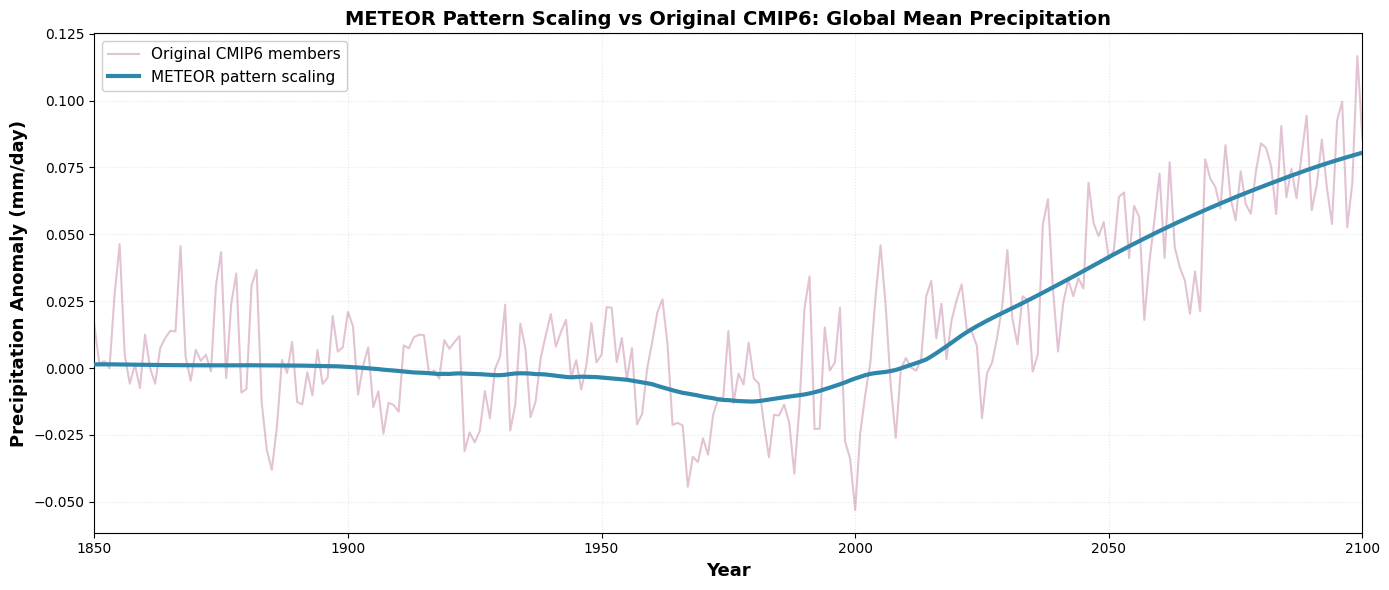


✅ Comparison plot created
   METEOR prediction: 351 years
   Original CMIP6: 251 years
   CMIP6 ensemble members: 1

💡 The METEOR pattern scaling captures the forced precipitation response
   without the internal variability present in individual CMIP6 members.


In [56]:
# Compare METEOR precipitation pattern scaling with original CMIP6 data
print("\n📊 Comparing METEOR precipitation pattern scaling with original CMIP6 data...")

# Get METEOR precipitation prediction (annual global mean)
meteor_pr_prediction_global = prpatt.global_mean(pr_prediction).values

# Create time axes
years_pr_original = np.arange(1850, 1850 + len(original_pr_ssp245_annual_mean.values[0]))
years_pr_meteor = np.arange(0, len(meteor_pr_prediction_global)) + 1750  # Starts at year 0

# Convert units: kg/m²/s to mm/day
# 1 kg/m²/s = 86400 mm/day (since 1 kg/m² of water = 1 mm depth)
meteor_pr_mm_day = meteor_pr_prediction_global * 86400
original_pr_mm_day = original_pr_ssp245_annual_mean.values * 86400

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original CMIP6 ensemble members
for i in range(pr_ssp245_annual.shape[0]):
    ax.plot(years_pr_original, original_pr_mm_day[i], 
            color='#A23B72', alpha=0.3, linewidth=1.5, 
            label='Original CMIP6 members' if i == 0 else '')

# Plot METEOR prediction
ax.plot(years_pr_meteor, meteor_pr_mm_day, 
        color='#2E86AB', linewidth=3, label='METEOR pattern scaling', 
        linestyle='-', zorder=10)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation Anomaly (mm/day)', fontsize=13, fontweight='bold')
ax.set_title('METEOR Pattern Scaling vs Original CMIP6: Global Mean Precipitation', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.show()

print(f"\n✅ Comparison plot created")
print(f"   METEOR prediction: {len(meteor_pr_prediction_global)} years")
print(f"   Original CMIP6: {len(original_pr_ssp245_annual_mean.values[0])} years")
print(f"   CMIP6 ensemble members: {pr_ssp245_annual.shape[0]}")
print("\n💡 The METEOR pattern scaling captures the forced precipitation response")
print("   without the internal variability present in individual CMIP6 members.")

In [80]:
## 9. Train Precipitation Noise Model and Generate Ensemble

In [228]:
# Train precipitation noise model from CMIP6 data
print("🎲 Setting up precipitation noise model...")

# Get cache path for noise model
pr_noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")
pr_noise_cache_file = pr_data_getter.get_noise_model_cache_path(
    pr_model_name, "pr", pr_noise_cache_dir
)

# Validate cache
is_valid_pr_noise, pr_noise_model, pr_noise_info = pr_data_getter.validate_noise_model_cache(
    pr_noise_cache_file, "pr", n_modes=40, lag_order=2
)

print(f"⚠️  {pr_noise_info['message']}")
print(f"🔧 Training precipitation noise model...")

# Convert to monthly
pr_monthly_prediction = pr_pattern_model.to_monthly(pr_prediction, start_year=0)
pr_monthly_warming = prpatt.global_mean(pr_monthly_prediction).values  # Use precipitation for conditioning

# Skip first 100 years (spin-up)
pr_monthy_warming=meteor_pr_prediction_global
pr_monthly_warming_trimmed = pr_monthly_warming[1200:]

# Train the noise model
pr_noise_model = train_noise_model_from_cmip6(
    pr_data_getter,
    experiments=["historical", "ssp245"],
    model_name=pr_model_name,
    variable_name="pr",
    n_modes=40,
    lag_order=2,
    custom_global_temp=pr_monthly_warming_trimmed,
    use_picontrol_baseline=True,
    cache_dir=pr_noise_cache_dir
)

print(f"✅ Precipitation noise model trained successfully")
print(f"   Training length: {len(pr_monthly_warming_trimmed)//12} years")

🎲 Setting up precipitation noise model...
Model loaded from /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/NorESM2-MM_pr_noise_model.pkl
⚠️  Cache valid: variable=pr, n_modes=40, lag_order=2
🔧 Training precipitation noise model...


INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr
INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr


   Fetched piControl baseline for NorESM2-MM pr: 0.000
Noise generator fitted successfully.
   - PCA modes: 40
   - Variance explained: 44.68%
   - VARX lag order: 2
Model saved to /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/NorESM2-MM_pr_noise_model.pkl
✅ Precipitation noise model trained successfully
   Training length: 251 years


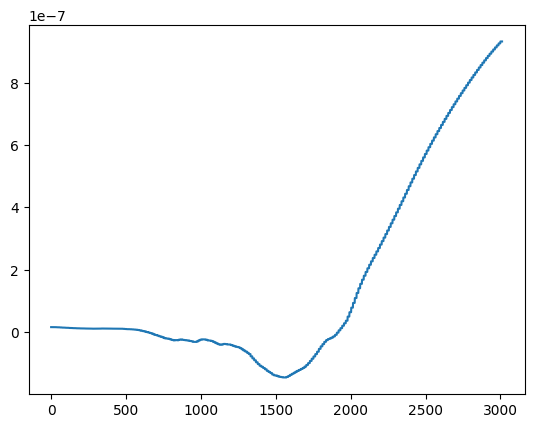

In [232]:
plt.plot(pr_monthly_warming_trimmed)

In [229]:
# Generate precipitation ensemble for global mean
print("🌧️  Generating precipitation ensemble...")

n_pr_demo = 100  # Generate 100 members for demonstration

# Generate stochastic PCs for precipitation
pr_demo_pcs = pr_noise_model.generate_stochastic_pcs(
    pr_monthly_warming,
    n_realizations=n_pr_demo,
    random_seed=789
)
print(f"✅ Generated {n_pr_demo} stochastic PCs for precipitation")

# Get piControl baseline for global mean
pr_pictrl_data = pr_data_getter.make_meteor_training_data(
    "piControl", 
    pr_model_name, 
    monthly=True
)["pr"]

pr_picontrol_global_baseline = prpatt.global_mean(pr_pictrl_data).mean()
print(f"   Global piControl precipitation baseline: {pr_picontrol_global_baseline.values:.6e} kg/m²/s ({pr_picontrol_global_baseline.values * 86400:.3f} mm/day)")

# Get pattern scaling prediction (anomaly) and add baseline
pr_monthly_prediction_global_anomaly = prpatt.global_mean(pr_monthly_prediction)
pr_monthly_prediction_global_absolute = pr_monthly_prediction_global_anomaly + pr_picontrol_global_baseline

# Generate global mean ensemble
pr_demo_global = pr_noise_model.generate_regional_mean_realizations(
    pr_monthly_warming,
    region='global',
    stochastic_pcs=pr_demo_pcs,
    noise_only=True,
    add_base=pr_monthly_prediction_global_absolute
)
print(f"✅ Global precipitation ensemble: {pr_demo_global.shape}")

# Load original CESM2 precipitation data
print("\n📥 Loading original CMIP6 global precipitation data...")
pr_ssp245_data = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=True
)["pr"]

# Calculate global mean for original data
original_pr_global = prpatt.global_mean(pr_ssp245_data)

print(f"✅ Original CMIP6 global precipitation loaded")
print(f"   Shape: {pr_ssp245_data.shape}")

🌧️  Generating precipitation ensemble...


INFO: Loading data from cache: NorESM2-MM_piControl_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/piControl/pr


✅ Generated 100 stochastic PCs for precipitation
   Global piControl precipitation baseline: 3.296076e-05 kg/m²/s (2.848 mm/day)


INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr


✅ Global precipitation ensemble: (100, 4212)

📥 Loading original CMIP6 global precipitation data...
✅ Original CMIP6 global precipitation loaded
   Shape: (1, 3012, 192, 288)


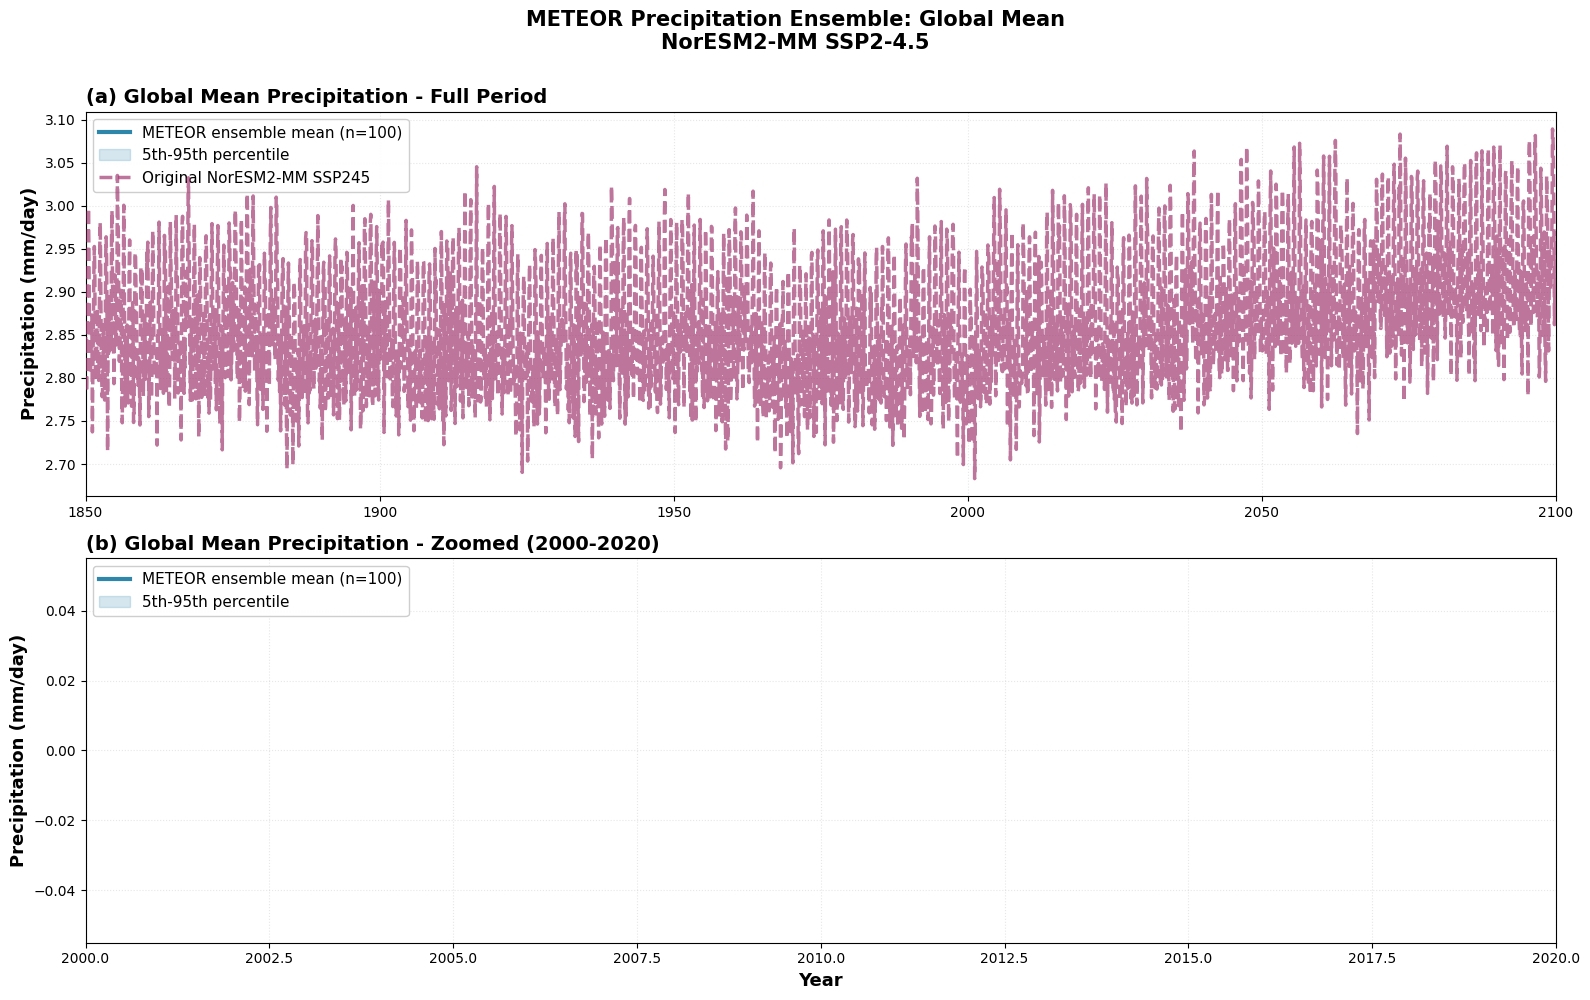


✅ Global mean precipitation ensemble plot created
   Ensemble size: 100 members
   Period: 1850-2100


In [230]:
# Plot global mean precipitation ensemble
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Convert to mm/day for plotting
pr_monthly_prediction_global_mm = pr_monthly_prediction_global_absolute * 86400
pr_demo_global_mm = pr_demo_global * 86400
original_pr_global_mm = original_pr_global * 86400

# Time axis
time_axis_pr = pr_ssp245_data['month'].values / 12 + 1850
offset = 1200  # Skip first 100 years

# Panel 1: Full period (1850-2100)
ax = axes[0]

# Plot ensemble members with transparency
for i in range(n_pr_demo):
    member_data = pr_demo_global_mm.isel(realization=i).values[offset:]
    time_mask_full = (time_axis_pr >= 1850) & (time_axis_pr <= 2100)
    ax.plot(time_axis_pr[time_mask_full], member_data[time_mask_full], 
            color='#2E86AB', alpha=0.015, linewidth=0.8)

# Plot ensemble mean
ensemble_mean_pr = pr_demo_global_mm.mean(dim='realization').values[offset:]
time_mask_full = (time_axis_pr >= 1850) & (time_axis_pr <= 2100)
ax.plot(time_axis_pr[time_mask_full], ensemble_mean_pr[time_mask_full], 
        color='#2E86AB', linewidth=3, label=f'METEOR ensemble mean (n={n_pr_demo})', zorder=10)

# Plot percentiles
perc_05_pr = pr_demo_global_mm.quantile(0.05, dim='realization').values[offset:]
perc_95_pr = pr_demo_global_mm.quantile(0.95, dim='realization').values[offset:]
ax.fill_between(time_axis_pr[time_mask_full], perc_05_pr[time_mask_full], perc_95_pr[time_mask_full],
                color='#2E86AB', alpha=0.2, label='5th-95th percentile', zorder=7)

# Plot original CMIP6 data
ax.plot(time_axis_pr[time_mask_full], original_pr_global_mm.values[:, time_mask_full].T, 
        color='#A23B72', linewidth=2.5, linestyle='--',
        label=f'Original {pr_model_name} SSP245', zorder=9, alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Precipitation - Full Period', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

# Panel 2: Zoomed period (2000-2020)
ax = axes[1]
zoom_start, zoom_end = 2000, 2020

# Plot ensemble members
for i in range(n_pr_demo):
    member_data = pr_demo_global_mm.isel(realization=i).values[offset:]
    time_mask_zoom = (time_axis_pr >= zoom_start) & (time_axis_pr <= zoom_end)
    ax.plot(time_axis_pr[time_mask_zoom], member_data[time_mask_zoom], 
            color='#2E86AB', alpha=0.015, linewidth=0.8)

# Plot ensemble mean
time_mask_zoom = (time_axis_pr >= zoom_start) & (time_axis_pr <= zoom_end)
ax.plot(time_axis_pr[time_mask_zoom], ensemble_mean_pr[time_mask_zoom], 
        color='#2E86AB', linewidth=3, label=f'METEOR ensemble mean (n={n_pr_demo})', zorder=10)

# Plot percentiles
ax.fill_between(time_axis_pr[time_mask_zoom], perc_05_pr[time_mask_zoom], perc_95_pr[time_mask_zoom],
                color='#2E86AB', alpha=0.2, label='5th-95th percentile', zorder=7)

# Plot original CMIP6 data
# ax.plot(time_axis_pr[time_mask_zoom], original_pr_global_mm.values[:, time_mask_zoom].T, 
#         color='#A23B72', linewidth=2.5, linestyle='--',
#         label=f'Original {pr_model_name} SSP245', zorder=9, alpha=0.7)

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation (mm/day)', fontsize=13, fontweight='bold')
ax.set_title(f'(b) Global Mean Precipitation - Zoomed ({zoom_start}-{zoom_end})', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(zoom_start, zoom_end)

plt.suptitle(f'METEOR Precipitation Ensemble: Global Mean\n{pr_model_name} SSP2-4.5', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"\n✅ Global mean precipitation ensemble plot created")
print(f"   Ensemble size: {n_pr_demo} members")
print(f"   Period: 1850-2100")

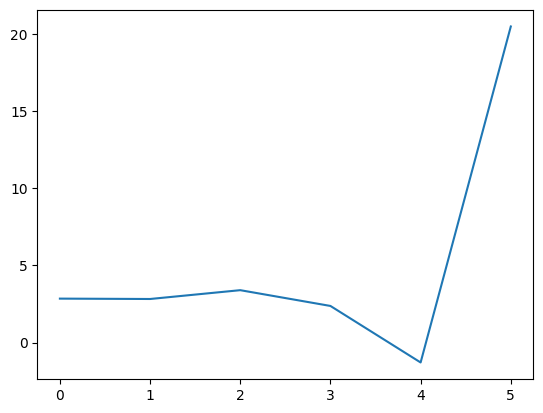

In [231]:
plt.plot(pr_demo_global_mm[0,:6])

In [123]:
# DIAGNOSTIC SEQUENCE: Harmonic Model Fitting for Precipitation
# This walks through each stage of MeteorNoiseGenerator.fit() to understand
# where the problematic seasonal cycle comes from

print("🔬 DIAGNOSTIC: Step-by-Step Harmonic Model Fitting for Precipitation")
print("="*80)
print("\nWe'll replicate the stages in noise_generator.py fit() method to see")
print("where the large seasonal cycle gets introduced.")
print("="*80)

🔬 DIAGNOSTIC: Step-by-Step Harmonic Model Fitting for Precipitation

We'll replicate the stages in noise_generator.py fit() method to see
where the large seasonal cycle gets introduced.


In [124]:
# STAGE 1: Load the training data (monthly CMIP6 precipitation)
print("\n" + "="*80)
print("STAGE 1: Load Monthly Training Data")
print("="*80)

# Load monthly precipitation data for training
pr_training_monthly = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=True
)["pr"]

# Load piControl baseline
pr_picontrol_monthly = pr_data_getter.make_meteor_training_data(
    "piControl", 
    pr_model_name, 
    monthly=True
)["pr"]

# Squeeze ensemble dimension if present
if 'ens' in pr_training_monthly.dims:
    pr_training_monthly = pr_training_monthly.squeeze('ens')

print(f"✅ Training data loaded:")
print(f"   Shape: {pr_training_monthly.shape}")
print(f"   Dims: {pr_training_monthly.dims}")
print(f"   Time range: {len(pr_training_monthly.month)} months")
print(f"   Spatial: {len(pr_training_monthly.lat)} lat × {len(pr_training_monthly.lon)} lon")

INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr



STAGE 1: Load Monthly Training Data


INFO: Loading data from cache: NorESM2-MM_piControl_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/piControl/pr
INFO: ✓ Using cached monthly data for NorESM2-MM/piControl/pr


✅ Training data loaded:
   Shape: (3012, 192, 288)
   Dims: ('month', 'lat', 'lon')
   Time range: 3012 months
   Spatial: 192 lat × 288 lon



STAGE 2: Calculate Global Mean Precipitation
✅ Global mean calculated:
   Raw global mean range: [8.943511e-03, 1.029674e-02] kg/m²/s
   PiControl baseline: 2.700646e-05 kg/m²/s
   Corrected range: [8.916504e-03, 1.026974e-02] kg/m²/s

✅ 60-month smoothing applied:
   Smoothed range: [9.351144e-03, 9.762303e-03] kg/m²/s
   Smoothed range (mm/day): [807.939, 843.463]
✅ Global mean calculated:
   Raw global mean range: [8.943511e-03, 1.029674e-02] kg/m²/s
   PiControl baseline: 2.700646e-05 kg/m²/s
   Corrected range: [8.916504e-03, 1.026974e-02] kg/m²/s

✅ 60-month smoothing applied:
   Smoothed range: [9.351144e-03, 9.762303e-03] kg/m²/s
   Smoothed range (mm/day): [807.939, 843.463]


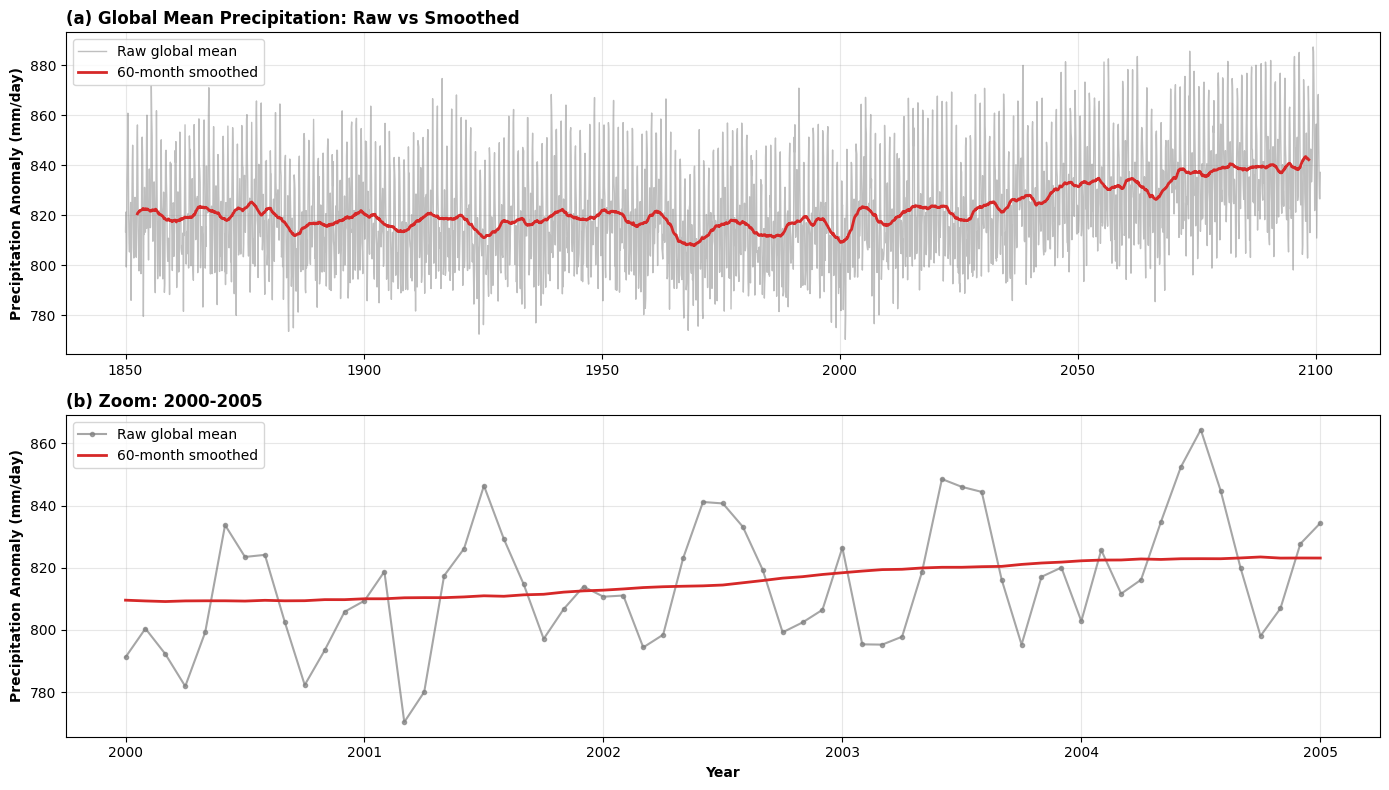


💡 Notice: 60-month smoothing removes high-frequency variability including
   the seasonal cycle from the global mean predictor.


In [125]:
# STAGE 2: Calculate Global Mean and Apply Smoothing
print("\n" + "="*80)
print("STAGE 2: Calculate Global Mean Precipitation")
print("="*80)

# Calculate area weights (cosine of latitude)
weights = np.cos(np.deg2rad(pr_training_monthly.lat))

# Calculate global mean
pr_global_weighted = (pr_training_monthly * weights).sum(['lat', 'lon']) / weights.sum()

# Apply piControl baseline correction
pr_picontrol_baseline = pr_picontrol_monthly.mean()
pr_global_baseline_corrected = pr_global_weighted - float(pr_picontrol_baseline.mean())

print(f"✅ Global mean calculated:")
print(f"   Raw global mean range: [{float(pr_global_weighted.min()):.6e}, {float(pr_global_weighted.max()):.6e}] kg/m²/s")
print(f"   PiControl baseline: {float(pr_picontrol_baseline.mean()):.6e} kg/m²/s")
print(f"   Corrected range: [{float(pr_global_baseline_corrected.min()):.6e}, {float(pr_global_baseline_corrected.max()):.6e}] kg/m²/s")

# Apply 60-month smoothing (as in noise_generator.py)
pr_global_smoothed = pr_global_baseline_corrected.rolling(month=60, center=True).mean()
pr_global_smoothed = pr_global_smoothed.interpolate_na(dim='month', method='linear')

print(f"\n✅ 60-month smoothing applied:")
print(f"   Smoothed range: [{float(pr_global_smoothed.min()):.6e}, {float(pr_global_smoothed.max()):.6e}] kg/m²/s")

# Convert to mm/day for interpretation
pr_global_smoothed_mm = pr_global_smoothed * 86400
print(f"   Smoothed range (mm/day): [{float(pr_global_smoothed_mm.min()):.3f}, {float(pr_global_smoothed_mm.max()):.3f}]")

# Plot to visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

time_years = pr_global_baseline_corrected.month.values / 12 + 1850

ax = axes[0]
ax.plot(time_years, (pr_global_baseline_corrected * 86400).values, 
        alpha=0.5, linewidth=1, label='Raw global mean', color='gray')
ax.plot(time_years, pr_global_smoothed_mm.values, 
        linewidth=2, label='60-month smoothed', color='#D62828')
ax.set_ylabel('Precipitation Anomaly (mm/day)', fontweight='bold')
ax.set_title('(a) Global Mean Precipitation: Raw vs Smoothed', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom to see seasonal cycle in raw data
ax = axes[1]
zoom_mask = (time_years >= 2000) & (time_years <= 2005)
ax.plot(time_years[zoom_mask], (pr_global_baseline_corrected.values[zoom_mask] * 86400), 
        alpha=0.7, linewidth=1.5, label='Raw global mean', color='gray', marker='o', markersize=3)
ax.plot(time_years[zoom_mask], pr_global_smoothed_mm.values[zoom_mask], 
        linewidth=2, label='60-month smoothed', color='#D62828')
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Precipitation Anomaly (mm/day)', fontweight='bold')
ax.set_title('(b) Zoom: 2000-2005', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Notice: 60-month smoothing removes high-frequency variability including")
print("   the seasonal cycle from the global mean predictor.")


STAGE 3: Create Harmonic Features (Seasonal Basis Functions)
✅ Basic harmonic features created:
   Time points: 3012
   Annual cycle: sin(2πt), cos(2πt)
   Semi-annual cycle: sin(4πt), cos(4πt)

✅ Full feature matrix created:
   Shape: (3012, 11)
   Features: 4 base harmonics + 4 modulated harmonics + 3 polynomial = 11 total


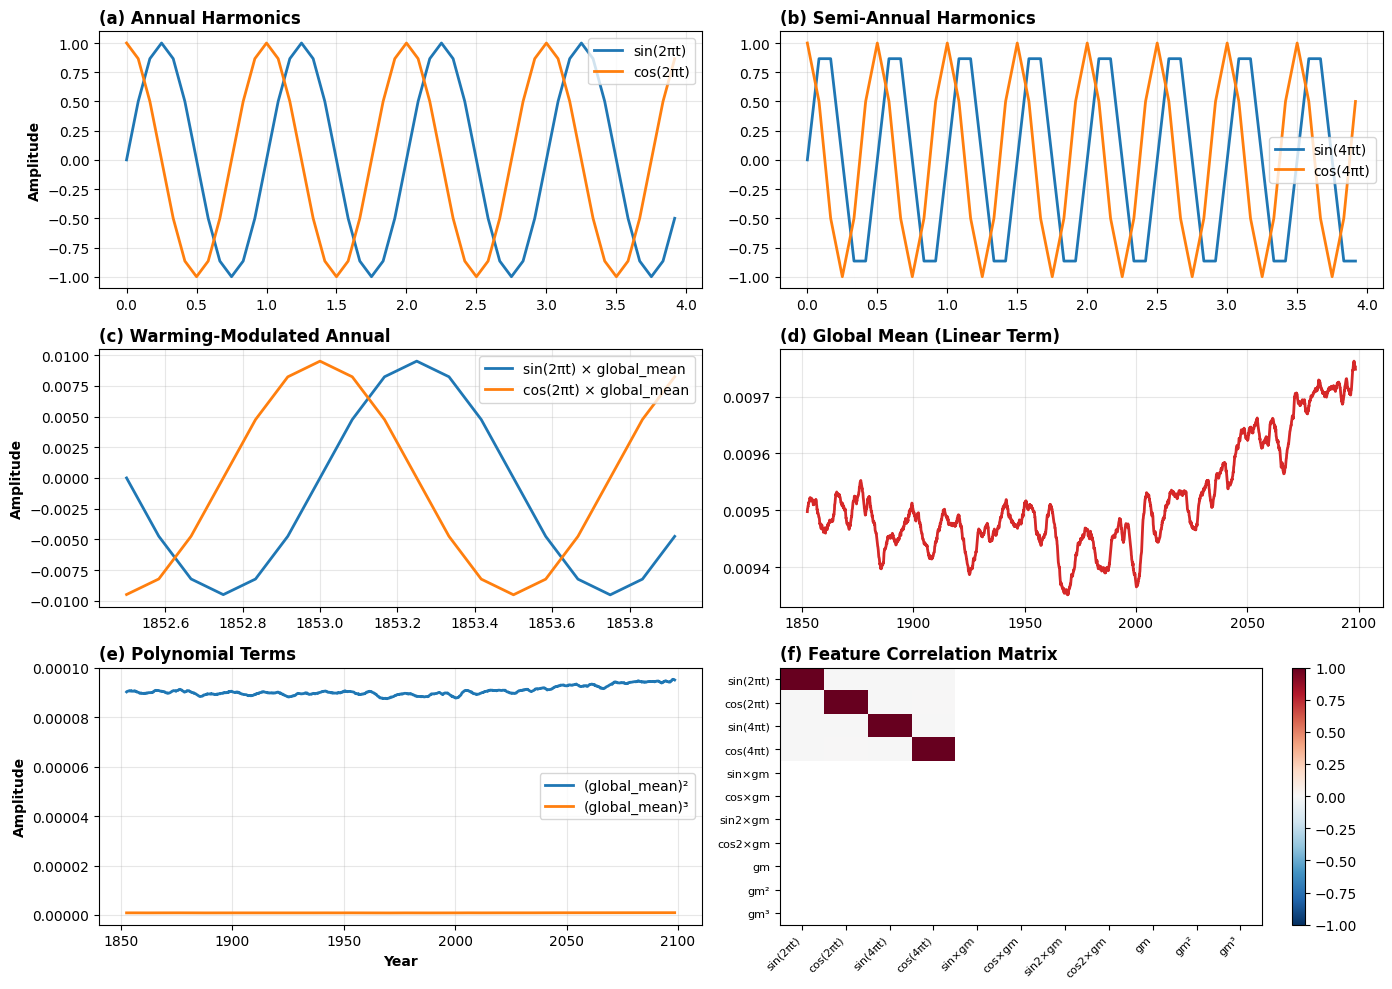


💡 Key observations:
   - Base harmonics are pure sinusoids (orthogonal)
   - Modulated harmonics scale with global warming trend
   - Polynomial terms capture non-linear trends
   - Features are designed to be added linearly: Y = β₀ + β₁X₁ + β₂X₂ + ...


In [129]:
# STAGE 3: Create Harmonic Features
print("\n" + "="*80)
print("STAGE 3: Create Harmonic Features (Seasonal Basis Functions)")
print("="*80)

n_time = len(pr_training_monthly.month)
t_norm = np.arange(n_time) / 12.0  # Convert to years

# Create seasonal harmonics
sin_annual = np.sin(2 * np.pi * t_norm)
cos_annual = np.cos(2 * np.pi * t_norm)
sin_semiannual = np.sin(4 * np.pi * t_norm)
cos_semiannual = np.cos(4 * np.pi * t_norm)

print(f"✅ Basic harmonic features created:")
print(f"   Time points: {n_time}")
print(f"   Annual cycle: sin(2πt), cos(2πt)")
print(f"   Semi-annual cycle: sin(4πt), cos(4πt)")

# Modulate by global mean (temperature-dependent seasonality)
# This assumes seasonal cycle amplitude changes with global warming
X_harmonic_base = np.column_stack([sin_annual, cos_annual, sin_semiannual, cos_semiannual])
X_harmonic_modulated = X_harmonic_base * pr_global_smoothed.values[:, np.newaxis]

# Add polynomial trend terms
X_poly = np.column_stack([
    pr_global_smoothed.values,      # Linear
    pr_global_smoothed.values**2,   # Quadratic
    pr_global_smoothed.values**3    # Cubic
])

# Combine all features
X_features = np.column_stack([
    X_harmonic_base,        # 4 features: base seasonal cycles
    X_harmonic_modulated,   # 4 features: warming-modulated seasonal cycles
    X_poly                  # 3 features: polynomial trends
])

print(f"\n✅ Full feature matrix created:")
print(f"   Shape: {X_features.shape}")
print(f"   Features: 4 base harmonics + 4 modulated harmonics + 3 polynomial = 11 total")

# Visualize the features
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Base harmonics
ax = axes[0, 0]
zoom = slice(0, 48)  # First 4 years
ax.plot(t_norm[zoom], sin_annual[zoom], label='sin(2πt)', linewidth=2)
ax.plot(t_norm[zoom], cos_annual[zoom], label='cos(2πt)', linewidth=2)
ax.set_title('(a) Annual Harmonics', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylabel('Amplitude', fontweight='bold')

ax = axes[0, 1]
ax.plot(t_norm[zoom], sin_semiannual[zoom], label='sin(4πt)', linewidth=2)
ax.plot(t_norm[zoom], cos_semiannual[zoom], label='cos(4πt)', linewidth=2)
ax.set_title('(b) Semi-Annual Harmonics', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

# Modulated harmonics
ax = axes[1, 0]
ax.plot(time_years[zoom], X_harmonic_modulated[zoom, 0], label='sin(2πt) × global_mean', linewidth=2)
ax.plot(time_years[zoom], X_harmonic_modulated[zoom, 1], label='cos(2πt) × global_mean', linewidth=2)
ax.set_title('(c) Warming-Modulated Annual', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylabel('Amplitude', fontweight='bold')

ax = axes[1, 1]
ax.plot(time_years, pr_global_smoothed.values, linewidth=2, color='#D62828')
ax.set_title('(d) Global Mean (Linear Term)', fontweight='bold', loc='left')
ax.grid(True, alpha=0.3)

# Polynomial terms
ax = axes[2, 0]
ax.plot(time_years, X_poly[:, 1], linewidth=2, label='(global_mean)²')
ax.plot(time_years, X_poly[:, 2], linewidth=2, label='(global_mean)³')
ax.set_title('(e) Polynomial Terms', fontweight='bold', loc='left')
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Amplitude', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Feature correlation matrix
ax = axes[2, 1]
feature_names = ['sin(2πt)', 'cos(2πt)', 'sin(4πt)', 'cos(4πt)', 
                 'sin×gm', 'cos×gm', 'sin2×gm', 'cos2×gm', 
                 'gm', 'gm²', 'gm³']
corr_matrix = np.corrcoef(X_features.T)
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(11))
ax.set_yticks(range(11))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_names, fontsize=8)
ax.set_title('(f) Feature Correlation Matrix', fontweight='bold', loc='left')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\n💡 Key observations:")
print("   - Base harmonics are pure sinusoids (orthogonal)")
print("   - Modulated harmonics scale with global warming trend")
print("   - Polynomial terms capture non-linear trends")
print("   - Features are designed to be added linearly: Y = β₀ + β₁X₁ + β₂X₂ + ...")

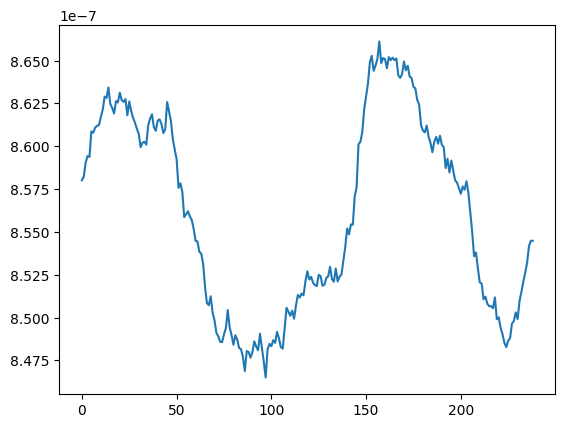

In [154]:
plt.plot(X_features_valid[1:240,10])

In [141]:
# STAGE 4 (CORRECTED): Fit Harmonic Regression with NaN Handling
print("\n" + "="*80)
print("STAGE 4: Fit Harmonic Regression (Grid Point by Grid Point)")
print("="*80)

# Stack spatial dimensions (as in noise_generator.py)
Y_stacked = pr_training_monthly.stack(space=('lat', 'lon'))
Y_values = Y_stacked.values  # Shape: (n_time, n_gridpoints)

print(f"✅ Target data prepared:")
print(f"   Shape: {Y_values.shape} (time × gridpoints)")
print(f"   Number of gridpoints: {Y_values.shape[1]:,}")

# CRITICAL FIX: Remove rows with NaNs from both X and Y
# The 60-month rolling window creates NaNs at the edges
valid_mask = ~np.any(np.isnan(X_features), axis=1)
n_valid = valid_mask.sum()
n_invalid = (~valid_mask).sum()

print(f"\n🔧 Handling NaNs from rolling window:")
print(f"   Valid time points: {n_valid} / {len(valid_mask)}")
print(f"   Invalid time points: {n_invalid} (first/last 30 months)")

# Filter to valid rows only
X_features_valid = X_features[valid_mask]
Y_values_valid = Y_values[valid_mask]

print(f"\n   Filtered X shape: {X_features_valid.shape}")
print(f"   Filtered Y shape: {Y_values_valid.shape}")

# Fit linear regression (same as in noise_generator.py)
from sklearn.linear_model import LinearRegression

print(f"\n🔧 Fitting LinearRegression(fit_intercept=True)...")
print(f"   This fits 11 coefficients + 1 intercept per grid point")
print(f"   Total parameters: {Y_values.shape[1]} gridpoints × 12 params = {Y_values.shape[1] * 12:,}")

seasonal_model = LinearRegression(fit_intercept=True)
seasonal_model.fit(X_features_valid, Y_values_valid)

print(f"\n✅ Regression fitted on {n_valid} valid time points:")
print(f"   Coefficients shape: {seasonal_model.coef_.shape}")
print(f"   Intercept shape: {seasonal_model.intercept_.shape}")

# Reconstruct fitted seasonal cycle (ONLY for valid time points)
seasonal_cycle_fit_valid = seasonal_model.predict(X_features_valid)

print(f"\n✅ Seasonal cycle reconstructed:")
print(f"   Shape: {seasonal_cycle_fit_valid.shape}")

# Create full array with NaNs at invalid positions
seasonal_cycle_fit_full = np.full((len(valid_mask), Y_values.shape[1]), np.nan)
seasonal_cycle_fit_full[valid_mask, :] = seasonal_cycle_fit_valid

print(f"   Full array (with NaNs): {seasonal_cycle_fit_full.shape}")

# Unstack back to spatial grid using the FULL array
seasonal_cycle_fit_xr = xr.DataArray(
    seasonal_cycle_fit_full, 
    coords=Y_stacked.coords,
    dims=Y_stacked.dims
).unstack('space')



STAGE 4: Fit Harmonic Regression (Grid Point by Grid Point)
✅ Target data prepared:
   Shape: (3012, 55296) (time × gridpoints)
   Number of gridpoints: 55,296

🔧 Handling NaNs from rolling window:
   Valid time points: 2953 / 3012
   Invalid time points: 59 (first/last 30 months)

   Filtered X shape: (2953, 11)
   Filtered Y shape: (2953, 55296)

🔧 Fitting LinearRegression(fit_intercept=True)...
   This fits 11 coefficients + 1 intercept per grid point
   Total parameters: 55296 gridpoints × 12 params = 663,552

   Filtered X shape: (2953, 11)
   Filtered Y shape: (2953, 55296)

🔧 Fitting LinearRegression(fit_intercept=True)...
   This fits 11 coefficients + 1 intercept per grid point
   Total parameters: 55296 gridpoints × 12 params = 663,552

✅ Regression fitted on 2953 valid time points:
   Coefficients shape: (55296, 11)
   Intercept shape: (55296,)

✅ Regression fitted on 2953 valid time points:
   Coefficients shape: (55296, 11)
   Intercept shape: (55296,)

✅ Seasonal cycle r


STAGE 5: Analyze the Fitted Seasonal Cycle

📊 Seasonal Cycle Analysis (2000-2019):
   Original data seasonal range: 53.536 mm/day
   Fitted seasonal range: 51.846 mm/day
   Ratio (fit/original): 0.968

📊 Seasonal Cycle Analysis (2000-2019):
   Original data seasonal range: 53.536 mm/day
   Fitted seasonal range: 51.846 mm/day
   Ratio (fit/original): 0.968


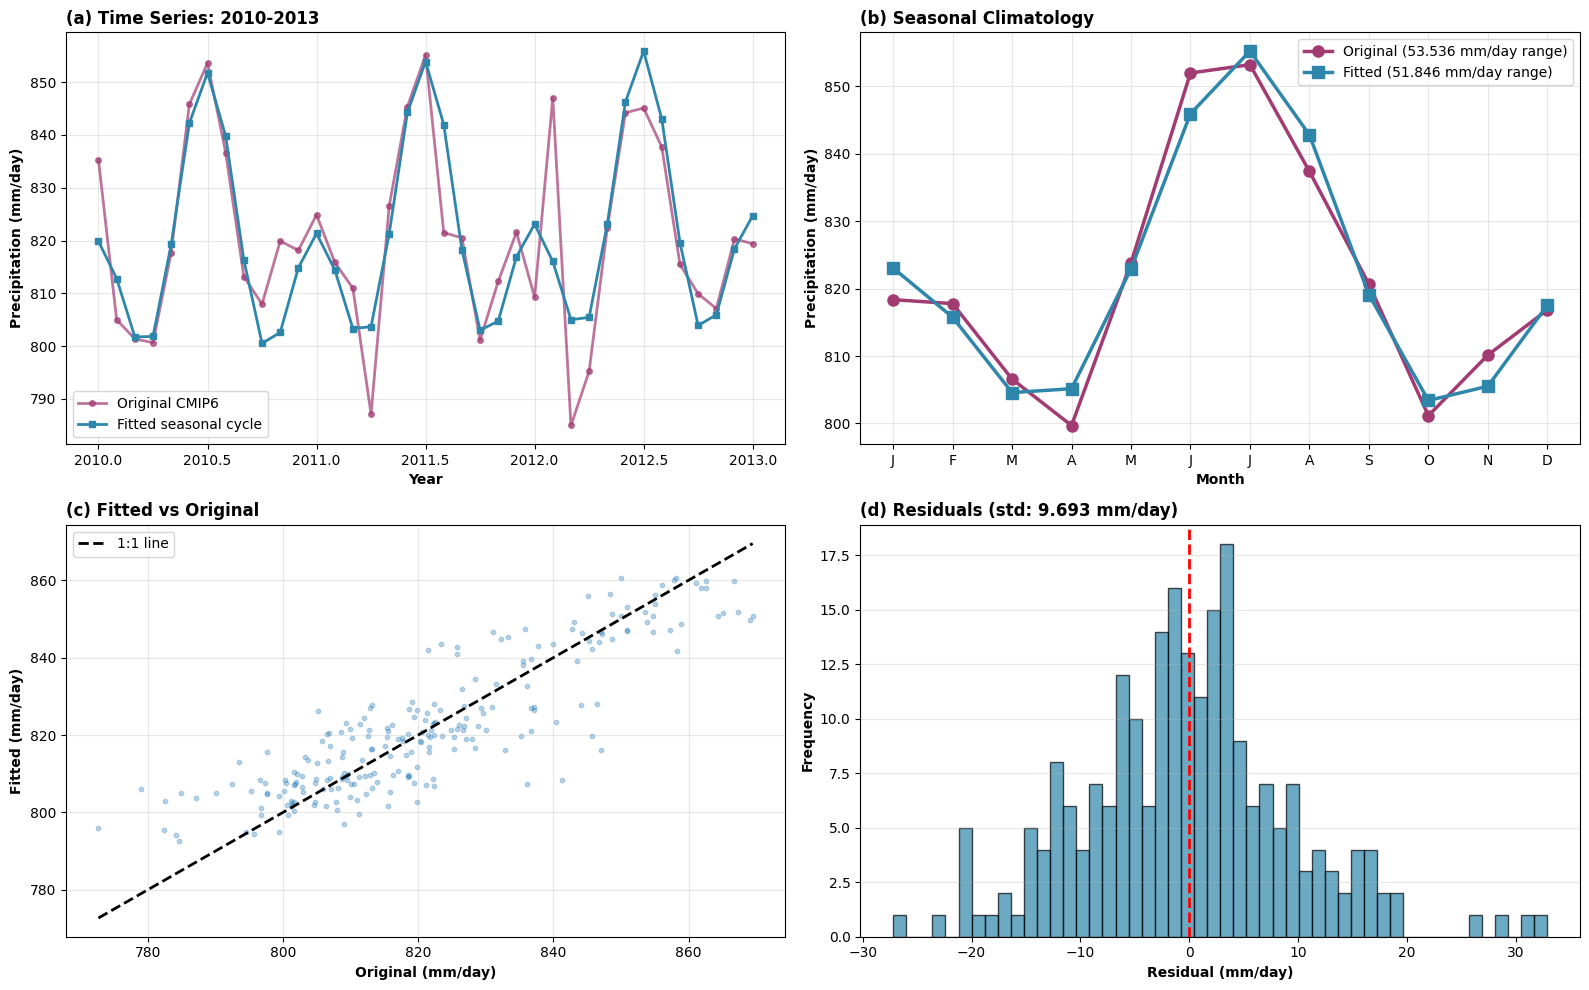


💡 Key finding:
   ⚠️  The fitted seasonal cycle has 51.846 mm/day range
   ⚠️  This is the seasonal cycle that will be in the 'noise' component!
   ⚠️  When pattern scaling has no seasonal cycle, noise model adds THIS


In [142]:
# STAGE 5: Analyze the Fitted Seasonal Cycle
print("\n" + "="*80)
print("STAGE 5: Analyze the Fitted Seasonal Cycle")
print("="*80)

# Calculate global mean of fitted seasonal cycle
seasonal_fit_global = (seasonal_cycle_fit_xr * weights).sum(['lat', 'lon']) / weights.sum()

# Calculate global mean of original data
original_global = (pr_training_monthly * weights).sum(['lat', 'lon']) / weights.sum()

# Convert to mm/day
seasonal_fit_global_mm = seasonal_fit_global * 86400
original_global_mm = original_global * 86400

# Analyze a period
period_mask = (time_years >= 2000) & (time_years <= 2019)

seasonal_fit_period = seasonal_fit_global_mm.values[period_mask]
original_period = original_global_mm.values[period_mask]

# Calculate month-of-year climatology
months_in_period = np.arange(len(seasonal_fit_period))
month_of_year = (months_in_period % 12) + 1

seasonal_fit_clim = np.array([seasonal_fit_period[month_of_year == m].mean() for m in range(1, 13)])
original_clim = np.array([original_period[month_of_year == m].mean() for m in range(1, 13)])

seasonal_fit_range = seasonal_fit_clim.max() - seasonal_fit_clim.min()
original_range = original_clim.max() - original_clim.min()

print(f"\n📊 Seasonal Cycle Analysis (2000-2019):")
print(f"   Original data seasonal range: {original_range:.3f} mm/day")
print(f"   Fitted seasonal range: {seasonal_fit_range:.3f} mm/day")
print(f"   Ratio (fit/original): {seasonal_fit_range / original_range:.3f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time series (3-year window)
ax = axes[0, 0]
window = (time_years >= 2010) & (time_years <= 2013)
ax.plot(time_years[window], original_global_mm.values[window], 
        'o-', color='#A23B72', linewidth=2, markersize=4, alpha=0.7,
        label='Original CMIP6')
ax.plot(time_years[window], seasonal_fit_global_mm.values[window], 
        's-', color='#2E86AB', linewidth=2, markersize=4,
        label='Fitted seasonal cycle')
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Precipitation (mm/day)', fontweight='bold')
ax.set_title('(a) Time Series: 2010-2013', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

# Seasonal climatology
ax = axes[0, 1]
months = np.arange(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax.plot(months, original_clim, 'o-', color='#A23B72', 
        linewidth=2.5, markersize=8, label=f'Original ({original_range:.3f} mm/day range)')
ax.plot(months, seasonal_fit_clim, 's-', color='#2E86AB', 
        linewidth=2.5, markersize=8, label=f'Fitted ({seasonal_fit_range:.3f} mm/day range)')
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Precipitation (mm/day)', fontweight='bold')
ax.set_title('(b) Seasonal Climatology', fontweight='bold', loc='left')
ax.set_xticks(months)
ax.set_xticklabels(month_names)
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter plot: Fitted vs Original
ax = axes[1, 0]
ax.scatter(original_global_mm.values[period_mask], seasonal_fit_global_mm.values[period_mask],
           alpha=0.3, s=10)
min_val = min(original_global_mm.values[period_mask].min(), seasonal_fit_global_mm.values[period_mask].min())
max_val = max(original_global_mm.values[period_mask].max(), seasonal_fit_global_mm.values[period_mask].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='1:1 line')
ax.set_xlabel('Original (mm/day)', fontweight='bold')
ax.set_ylabel('Fitted (mm/day)', fontweight='bold')
ax.set_title('(c) Fitted vs Original', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

# Residual analysis
residuals = original_global_mm.values[period_mask] - seasonal_fit_global_mm.values[period_mask]
ax = axes[1, 1]
ax.hist(residuals, bins=50, alpha=0.7, color='#2E86AB', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (mm/day)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title(f'(d) Residuals (std: {residuals.std():.3f} mm/day)', 
             fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Key finding:")
if seasonal_fit_range > 0.1:
    print(f"   ⚠️  The fitted seasonal cycle has {seasonal_fit_range:.3f} mm/day range")
    print("   ⚠️  This is the seasonal cycle that will be in the 'noise' component!")
    print("   ⚠️  When pattern scaling has no seasonal cycle, noise model adds THIS")
else:
    print(f"   ✅ Fitted seasonal range is small ({seasonal_fit_range:.3f} mm/day)")